# Customer Churn Survival Analysis

## Why Survival Analysis, Not Classification?

Classification asks: **"Will this customer churn? Yes/No."** This forces an arbitrary time window and produces a binary label that depends on *when* you ask the question.

Survival analysis asks: **"How long does a customer stay active before they churn?"** This is the natural framing:
- **Duration** = Last purchase date − First purchase date (customer lifetime)
- **Event** = churned (last purchase > 45 days before observation end) or censored (still possibly active)
- The output is a **survival curve per customer** — the probability of remaining active over time
- No need to fragment one customer into multiple rows — one row per customer, clean and independent

---

### Notebook Structure

| Part | Description |
|------|-------------|
| **Part 1** | Data Loading & Cleaning |
| **Part 2** | RFM Summary + Lifetimes BG/NBD & Gamma-Gamma (P(alive), CLV, Expected Txns) |
| **Part 3** | PCA + K-Means Clustering: Gold, Silver, Bronze + One-Timers |
| **Part 4** | Kaplan-Meier Survival Curves: Overall + Per Segment |
| **Part 5** | Cox Proportional Hazards (Baseline Survival Model) |
| **Part 6** | Random Survival Forest + XGBoost Survival (Rich Features) |

---
## Part 1: Data Loading & Cleaning

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Lifetimes (BG/NBD, Gamma-Gamma)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Survival Analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# Survival ML (scikit-survival)
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    concordance_index_ipcw,
    cumulative_dynamic_auc,
    brier_score,
    integrated_brier_score,
)
import xgboost as xgb

# ML utilities
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from scipy.ndimage import gaussian_filter1d

print('All imports loaded.')

All imports loaded.


In [2]:
# Load the dataset
df = pd.read_csv('../data/online_retail_II.csv')
print(f'Raw dataset shape: {df.shape}')
df.head()

Raw dataset shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# --- Data Cleaning ---

# Remove missing Customer ID
df = df[df['Customer ID'].notna()]

# Remove canceled transactions (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero Quantity and Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove exact duplicates
df.drop_duplicates(inplace=True)

# Compute line total
df['LineTotal'] = df['Quantity'] * df['Price']

print(f'Cleaned dataset shape: {df.shape}')
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Countries: {df['Country'].nunique()}")

Cleaned dataset shape: (779425, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5878
Countries: 41


In [4]:
# --- IQR Outlier Removal ---

for col in ['Quantity', 'Price']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

# Recompute LineTotal after outlier removal
df['LineTotal'] = df['Quantity'] * df['Price']

print(f'After outlier removal: {df.shape}')
print(f'Quantity range: {df["Quantity"].min()} - {df["Quantity"].max()}')
print(f'Price range: {df["Price"].min():.2f} - {df["Price"].max():.2f}')

After outlier removal: (663373, 9)
Quantity range: 1 - 27
Price range: 0.00 - 7.50


---
## Part 2: RFM Summary + Lifetimes Probabilistic Models

We use the **`lifetimes`** library to fit:
1. **BG/NBD model** — predicts future transaction count and probability of being "alive"
2. **Gamma-Gamma model** — predicts expected average monetary value per transaction

From these we derive per-customer:
- **Recency**: days since last purchase (relative to first purchase)
- **Frequency**: number of repeat purchases
- **Monetary**: average spend per transaction
- **T**: customer age (days since first purchase to end of observation)
- **P(alive)**: probability the customer is still active
- **Expected transactions (6 months)**: predicted number of purchases in next 180 days
- **Estimated CLV (6 months)**: predicted customer lifetime value over next 180 days

In [5]:
# --- Build RFM summary using lifetimes ---
# lifetimes expects: customer_id, transaction date, and optionally monetary value

# Observation period end date
observation_end = df['InvoiceDate'].max()
print(f'Observation period ends: {observation_end}')

# Aggregate to invoice level first (one row per customer per visit)
invoice_totals = (
    df.groupby(['Customer ID', 'Invoice'])
    .agg(
        InvoiceDate=('InvoiceDate', 'min'),
        Revenue=('LineTotal', 'sum')
    )
    .reset_index()
)

# Build RFM summary table using lifetimes utility
rfm = summary_data_from_transaction_data(
    transactions=invoice_totals,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='Revenue',
    observation_period_end=observation_end
)

print(f'RFM summary shape: {rfm.shape}')
print(f'\nRFM statistics:')
print(rfm.describe().round(2))
rfm.head(10)

Observation period ends: 2011-12-09 12:50:00
RFM summary shape: (5675, 4)

RFM statistics:
       frequency  recency        T  monetary_value
count     5675.0  5675.00  5675.00         5675.00
mean         4.4   270.70   471.03          180.43
std          9.4   257.53   223.85          203.20
min          0.0     0.00     0.00            0.00
25%          0.0     0.00   308.00            0.00
50%          2.0   217.00   526.00          144.31
75%          5.0   506.00   665.50          268.85
max        245.0   738.00   738.00         3396.64


,frequency,recency,T,monetary_value
Customer ID,,,,
12346.0,6.0,196.0,725.0,47.143333
12347.0,7.0,402.0,404.0,473.532857
12348.0,3.0,190.0,438.0,30.066667
12349.0,2.0,571.0,589.0,920.260000
12350.0,0.0,0.0,310.0,0.000000
12351.0,0.0,0.0,375.0,0.000000
12352.0,8.0,356.0,392.0,164.780000
12353.0,1.0,204.0,408.0,29.300000
12354.0,0.0,0.0,232.0,0.000000


In [6]:
# --- Separate one-timers from repeat customers ---
# One-timers: frequency = 0 (only one purchase ever)
# The BG/NBD model needs frequency >= 1 for meaningful estimates

one_timers = rfm[rfm['frequency'] == 0].copy()
repeat_customers = rfm[rfm['frequency'] > 0].copy()

print(f'One-time buyers: {len(one_timers):,} ({len(one_timers)/len(rfm)*100:.1f}%)')
print(f'Repeat customers: {len(repeat_customers):,} ({len(repeat_customers)/len(rfm)*100:.1f}%)')

One-time buyers: 1,645 (29.0%)
Repeat customers: 4,030 (71.0%)


In [7]:
# --- Fit BG/NBD model ---
# Models the number of future transactions and P(alive)

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    frequency=rfm['frequency'],
    recency=rfm['recency'],
    T=rfm['T']
)

print('BG/NBD Model Parameters:')
print(bgf.summary)

BG/NBD Model Parameters:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.669697  0.016067         0.638205         0.701188
alpha  66.549935  2.061923        62.508565        70.591305
a       0.044830  0.004568         0.035876         0.053784
b       0.580866  0.055616         0.471859         0.689872


In [8]:
# --- BG/NBD predictions for ALL customers ---

# P(alive) — probability customer is still active
rfm['p_alive'] = bgf.conditional_probability_alive(
    frequency=rfm['frequency'],
    recency=rfm['recency'],
    T=rfm['T']
)

# Expected transactions in next 180 days (6 months)
rfm['expected_txns_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t=180,
    frequency=rfm['frequency'],
    recency=rfm['recency'],
    T=rfm['T']
)

print('BG/NBD predictions computed.')
print(f'\nP(alive) distribution:')
print(rfm['p_alive'].describe().round(4))
print(f'\nExpected transactions (6 months) distribution:')
print(rfm['expected_txns_6m'].describe().round(4))

BG/NBD predictions computed.

P(alive) distribution:
count    5675.0000
mean        0.9120
std         0.1697
min         0.0000
25%         0.9172
50%         0.9858
75%         1.0000
max         1.0000
Name: p_alive, dtype: float64

Expected transactions (6 months) distribution:
count    5114.0000
mean        1.6012
std         2.4011
min         0.0000
25%         0.3114
50%         0.9011
75%         2.0558
max        54.6921
Name: expected_txns_6m, dtype: float64


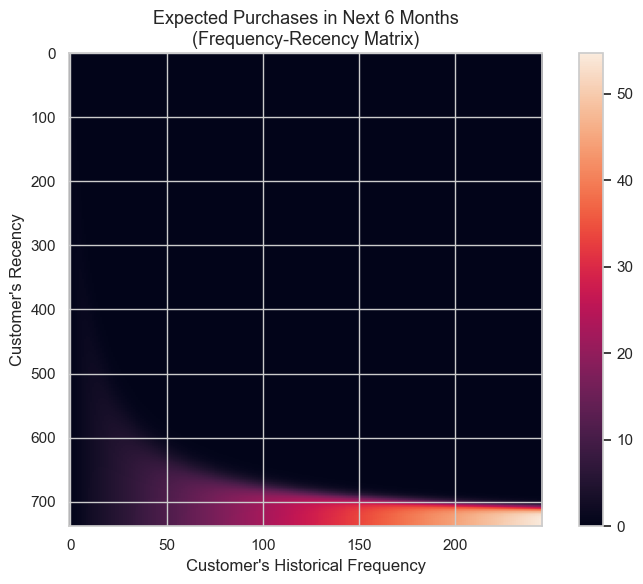

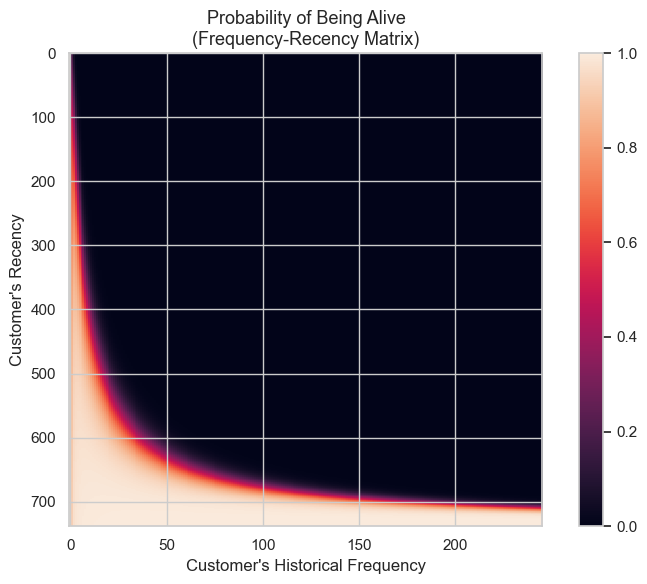

In [9]:
# --- BG/NBD Diagnostic Plots ---
# lifetimes plotting functions create their own figure internally,
# so we render them as separate figures instead of fighting with subplots.

# 1. Frequency-Recency Matrix
plt.figure(figsize=(8, 6))
plot_frequency_recency_matrix(bgf, T=180)
plt.title('Expected Purchases in Next 6 Months\n(Frequency-Recency Matrix)', fontsize=13)
plt.tight_layout()
plt.show()

# 2. Probability Alive Matrix
plt.figure(figsize=(8, 6))
plot_probability_alive_matrix(bgf)
plt.title('Probability of Being Alive\n(Frequency-Recency Matrix)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# --- Fit Gamma-Gamma model (on repeat customers only) ---
# The Gamma-Gamma model predicts average monetary value per transaction.
# It requires frequency > 0 (at least 2 purchases to estimate spend variability).

# Filter repeat customers for Gamma-Gamma
rfm_repeat = rfm[rfm['frequency'] > 0].copy()

# Gamma-Gamma assumes no correlation between frequency and monetary
corr = rfm_repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'Correlation between frequency and monetary_value: {corr:.4f}')
print('(Gamma-Gamma assumes this is low)')

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    frequency=rfm_repeat['frequency'],
    monetary_value=rfm_repeat['monetary_value']
)

print('\nGamma-Gamma Model Parameters:')
print(ggf.summary)

Correlation between frequency and monetary_value: 0.0802
(Gamma-Gamma assumes this is low)

Gamma-Gamma Model Parameters:
       coef  se(coef)  lower 95% bound  upper 95% bound
p  3.856092  0.080042         3.699210         4.012974
q  0.388198  0.007010         0.374458         0.401939
v  3.758744  0.080983         3.600017         3.917470


In [11]:
# --- CLV estimation (6 months) for repeat customers ---

# Expected average monetary value per transaction
rfm.loc[rfm['frequency'] > 0, 'avg_monetary_predicted'] = ggf.conditional_expected_average_profit(
    frequency=rfm_repeat['frequency'],
    monetary_value=rfm_repeat['monetary_value']
)
# For one-timers: use the overall median as a conservative estimate
rfm['avg_monetary_predicted'] = rfm['avg_monetary_predicted'].fillna(
    rfm.loc[rfm['frequency'] > 0, 'avg_monetary_predicted'].median()
)

# CLV = expected_txns * expected_avg_monetary
rfm['clv_6m'] = rfm['expected_txns_6m'] * rfm['avg_monetary_predicted']

print('CLV (6 months) computed.')
print(f'\nCLV distribution:')
print(rfm['clv_6m'].describe().round(2))

# Summary of all computed features
print(f'\nFull customer feature table:')
rfm[['frequency', 'recency', 'T', 'monetary_value', 'p_alive', 
     'expected_txns_6m', 'avg_monetary_predicted', 'clv_6m']].describe().round(2)

CLV (6 months) computed.

CLV distribution:
count     5114.00
mean       453.25
std       1061.95
min          0.00
25%         58.58
50%        184.85
75%        529.38
max      39767.34
Name: clv_6m, dtype: float64

Full customer feature table:


,frequency,recency,T,monetary_value,p_alive,expected_txns_6m,avg_monetary_predicted,clv_6m
count,5675.0,5675.00,5675.00,5675.00,5675.00,5114.00,5675.00,5114.00
mean,4.4,270.70,471.03,180.43,0.91,1.60,260.86,453.25
std,9.4,257.53,223.85,203.20,0.17,2.40,183.08,1061.95
min,0.0,0.00,0.00,0.00,0.00,0.00,5.60,0.00
25%,0.0,0.00,308.00,0.00,0.92,0.31,175.61,58.58
50%,2.0,217.00,526.00,144.31,0.99,0.90,228.19,184.85
75%,5.0,506.00,665.50,268.85,1.00,2.06,288.28,529.38
max,245.0,738.00,738.00,3396.64,1.00,54.69,4041.64,39767.34


---
## Part 3: Customer Segmentation — PCA + K-Means

We cluster **repeat customers** (frequency > 0) into 3 segments:
- **Gold**: highest revenue, frequency, CLV, and P(alive)
- **Silver**: middle tier
- **Bronze**: lowest among repeat customers

**One-timers** are excluded from clustering — they are a separate segment with insufficient history. For survival analysis, we assume their survival curve resembles the Bronze segment.

### Approach
1. Standardize features
2. Apply PCA to reduce to 3 components
3. K-Means with K=3
4. Label clusters based on feature means (Gold > Silver > Bronze)

In [12]:
# --- Prepare features for PCA + Clustering ---
# Use only BEHAVIORAL features (observed until time T, no forward-looking predictions)
# EXCLUDED: p_alive, expected_txns_6m, avg_monetary_predicted, clv_6m
#   → These leak churn info (p_alive≈0 means churned, expected_txns=0 means inactive)

rfm_repeat_cluster = rfm[rfm['frequency'] > 0].copy()

cluster_features = ['frequency', 'recency', 'monetary_value', 'T']

X_cluster = rfm_repeat_cluster[cluster_features].copy()

# Standardize
scaler_cluster = StandardScaler()
X_cluster_sc = scaler_cluster.fit_transform(X_cluster)

print(f'Clustering on {len(rfm_repeat_cluster):,} repeat customers')
print(f'Features (behavioral only, no leakage): {cluster_features}')
print(f'EXCLUDED: p_alive, expected_txns_6m, clv_6m (forward-looking → leaks churn info)')

Clustering on 4,030 repeat customers
Features (behavioral only, no leakage): ['frequency', 'recency', 'monetary_value', 'T']
EXCLUDED: p_alive, expected_txns_6m, clv_6m (forward-looking → leaks churn info)


In [13]:
# --- PCA: Reduce to 3 components ---

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_cluster_sc)

print('PCA Explained Variance Ratio:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.1f}%)')
print(f'  Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)')

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=cluster_features
)
print('\nPCA Loadings:')
print(loadings.round(3))

PCA Explained Variance Ratio:
  PC1: 0.4991 (49.9%)
  PC2: 0.2417 (24.2%)
  PC3: 0.1917 (19.2%)
  Total: 0.9326 (93.3%)

PCA Loadings:
                  PC1    PC2    PC3
frequency       0.449 -0.090  0.869
recency         0.641 -0.070 -0.181
monetary_value  0.190  0.979 -0.012
T               0.592 -0.169 -0.460


In [14]:
# --- K-Means Clustering (K=3) on PCA components ---

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_repeat_cluster['cluster_raw'] = kmeans.fit_predict(X_pca)

# Compute cluster means to assign Gold/Silver/Bronze labels
cluster_means = rfm_repeat_cluster.groupby('cluster_raw')[cluster_features].mean()

# Rank clusters by monetary_value (Gold = highest spend, Bronze = lowest)
# Using monetary_value instead of clv_6m to avoid leakage
cluster_rank = cluster_means['monetary_value'].sort_values(ascending=False)
label_map = {}
tier_names = ['Gold', 'Silver', 'Bronze']
for rank_idx, (cluster_id, _) in enumerate(cluster_rank.items()):
    label_map[cluster_id] = tier_names[rank_idx]

rfm_repeat_cluster['segment'] = rfm_repeat_cluster['cluster_raw'].map(label_map)

print('Cluster label mapping (by monetary_value):')
for k, v in label_map.items():
    print(f'  Cluster {k} -> {v}')

print(f'\nSegment sizes:')
print(rfm_repeat_cluster['segment'].value_counts())

Cluster label mapping (by monetary_value):
  Cluster 2 -> Gold
  Cluster 1 -> Silver
  Cluster 0 -> Bronze

Segment sizes:
segment
Bronze    2075
Silver    1108
Gold       847
Name: count, dtype: int64


In [15]:
# --- Cluster profiles ---

print('=== Cluster Profiles ===')
print()

for segment in ['Gold', 'Silver', 'Bronze']:
    seg_data = rfm_repeat_cluster[rfm_repeat_cluster['segment'] == segment]
    print(f'--- {segment} ({len(seg_data):,} customers) ---')
    print(f'  Avg Frequency:        {seg_data["frequency"].mean():.1f}')
    print(f'  Avg Recency:          {seg_data["recency"].mean():.1f} days')
    print(f'  Avg Monetary/Txn:     £{seg_data["monetary_value"].mean():.2f}')
    print(f'  Avg Customer Age (T): {seg_data["T"].mean():.1f} days')
    print()

=== Cluster Profiles ===

--- Gold (847 customers) ---
  Avg Frequency:        16.4
  Avg Recency:          641.1 days
  Avg Monetary/Txn:     £417.23
  Avg Customer Age (T): 684.7 days

--- Silver (1,108 customers) ---
  Avg Frequency:        2.4
  Avg Recency:          121.6 days
  Avg Monetary/Txn:     £216.31
  Avg Customer Age (T): 255.5 days

--- Bronze (2,075 customers) ---
  Avg Frequency:        4.0
  Avg Recency:          413.7 days
  Avg Monetary/Txn:     £207.66
  Avg Customer Age (T): 595.1 days



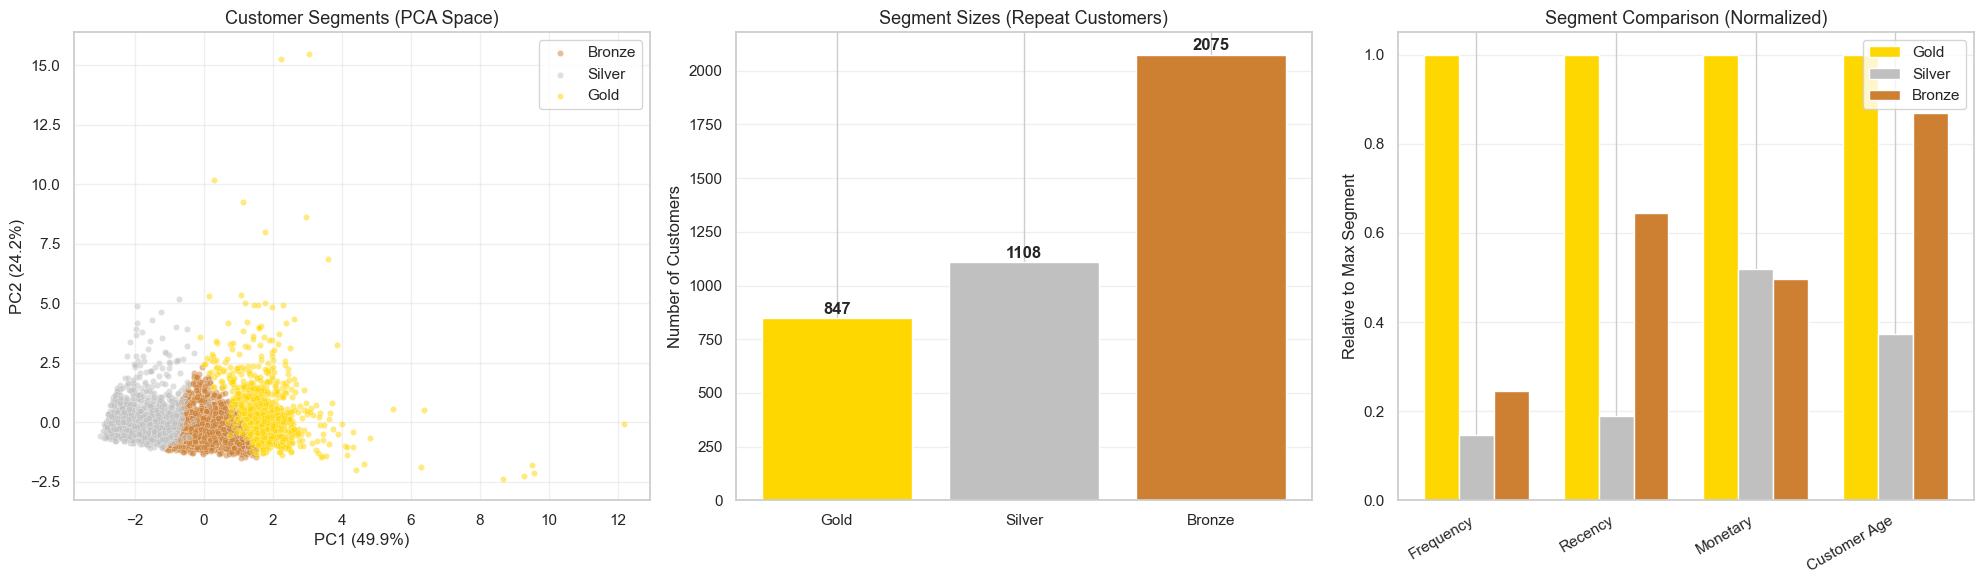

In [16]:
# --- Visualization: PCA scatter + segment profiles ---

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA scatter (PC1 vs PC2)
segment_colors = {'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'}
for seg in ['Bronze', 'Silver', 'Gold']:
    mask = rfm_repeat_cluster['segment'] == seg
    axes[0].scatter(
        X_pca[mask.values, 0], X_pca[mask.values, 1],
        c=segment_colors[seg], label=seg, alpha=0.5, s=20, edgecolors='white', linewidth=0.3
    )
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Customer Segments (PCA Space)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Segment size bar chart
seg_counts = rfm_repeat_cluster['segment'].value_counts().reindex(['Gold', 'Silver', 'Bronze'])
bars = axes[1].bar(seg_counts.index, seg_counts.values,
                   color=[segment_colors[s] for s in seg_counts.index], edgecolor='white')
for bar, count in zip(bars, seg_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(count), ha='center', fontweight='bold')
axes[1].set_title('Segment Sizes (Repeat Customers)', fontsize=13)
axes[1].set_ylabel('Number of Customers')
axes[1].grid(True, alpha=0.3, axis='y')

# Segment comparison (behavioral features only)
compare_features = ['frequency', 'recency', 'monetary_value', 'T']
compare_labels = ['Frequency', 'Recency', 'Monetary', 'Customer Age']
x_pos = np.arange(len(compare_features))
width = 0.25

for i, seg in enumerate(['Gold', 'Silver', 'Bronze']):
    seg_means = rfm_repeat_cluster[rfm_repeat_cluster['segment'] == seg][compare_features].mean()
    max_vals = rfm_repeat_cluster.groupby('segment')[compare_features].mean().max()
    normalized = seg_means / max_vals
    axes[2].bar(x_pos + i * width, normalized.values, width,
               label=seg, color=segment_colors[seg], edgecolor='white')

axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels(compare_labels, rotation=30, ha='right')
axes[2].set_title('Segment Comparison (Normalized)', fontsize=13)
axes[2].set_ylabel('Relative to Max Segment')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [17]:
# --- Merge segment labels back to the full RFM table ---
# One-timers get their own segment label

rfm['segment'] = 'One-Timer'
rfm.loc[rfm_repeat_cluster.index, 'segment'] = rfm_repeat_cluster['segment']

print('Full customer segmentation:')
print(rfm['segment'].value_counts())
print(f'\nTotal customers: {len(rfm):,}')

Full customer segmentation:
segment
Bronze       2075
One-Timer    1645
Silver       1108
Gold          847
Name: count, dtype: int64

Total customers: 5,675


---
## Part 4: Kaplan-Meier Survival Curves

### Customer-Level Survival Framing

Each customer is **one row**. The survival question is: **"How long does this customer stay active in the business?"**

- **Duration** = Last purchase date − First purchase date (total customer lifetime in days)
- **Event (churn)** = 1 if the customer's last purchase was **more than 45 days** before the observation end date (business rule: churn_45). They had time to come back and didn't.
- **Censored** = 0 if the customer's last purchase was **within 45 days** of the observation end. They might still be active — we just don't have enough observation time to know.

This is fundamentally different from the gap-level approach:
- **One row per customer** — no independence violations
- Duration measures **total tenure**, not inter-visit gaps
- The event is a **business rule** (churn_45), not an artifact of data structure

In [18]:
# --- Build CUSTOMER-LEVEL survival dataset ---
# One row per customer.
# Duration = last purchase date - first purchase date (customer lifetime)
# Event = 1 (churned) if last purchase > 45 days before observation end
# Event = 0 (censored) if last purchase within 45 days of observation end

CHURN_WINDOW = 45  # business rule

# Compute first and last purchase per customer
customer_dates = (
    df.groupby('Customer ID')
    .agg(
        first_purchase=('InvoiceDate', 'min'),
        last_purchase=('InvoiceDate', 'max')
    )
)

# Duration: customer lifetime in days
customer_dates['duration'] = (customer_dates['last_purchase'] - customer_dates['first_purchase']).dt.days

# Days from last purchase to observation end
customer_dates['days_since_last'] = (observation_end - customer_dates['last_purchase']).dt.days

# Event: churned if last purchase was > 45 days before observation end
# Censored if last purchase was within 45 days (they might still be active)
customer_dates['event_observed'] = (customer_dates['days_since_last'] > CHURN_WINDOW).astype(int)

# For one-timers: duration = 0 (first = last), but they can still be churned
# We keep them — their duration is 0, which is valid (they churned immediately or are censored)

# Merge segment info
customer_surv = customer_dates.merge(
    rfm[['segment']],
    left_index=True,
    right_index=True,
    how='left'
)

print(f'Customer-level survival dataset: {len(customer_surv):,} customers')
print(f'Churned (event=1): {customer_surv["event_observed"].sum():,} ({customer_surv["event_observed"].mean()*100:.1f}%)')
print(f'Censored (event=0): {(1-customer_surv["event_observed"]).sum():,} ({(1-customer_surv["event_observed"]).mean()*100:.1f}%)')
print(f'Churn window: {CHURN_WINDOW} days')
print(f'\nDuration (customer lifetime) statistics:')
print(customer_surv['duration'].describe().round(1))
print(f'\nDays since last purchase:')
print(customer_surv['days_since_last'].describe().round(1))

# Show examples
print(f'\nSample rows:')
customer_surv[['first_purchase', 'last_purchase', 'duration', 'days_since_last', 'event_observed', 'segment']].head(10)

Customer-level survival dataset: 5,675 customers
Churned (event=1): 3,652 (64.4%)
Censored (event=0): 2,023 (35.6%)
Churn window: 45 days

Duration (customer lifetime) statistics:
count    5675.0
mean      270.3
std       257.4
min         0.0
25%         0.0
50%       216.0
75%       505.0
max       738.0
Name: duration, dtype: float64

Days since last purchase:
count    5675.0
mean      199.8
std       208.7
min         0.0
25%        25.0
50%        94.0
75%       379.0
max       738.0
Name: days_since_last, dtype: float64

Sample rows:


,first_purchase,last_purchase,duration,days_since_last,event_observed,segment
Customer ID,,,,,,
12346.0,2009-12-14 08:34:00,2010-06-28 13:53:00,196,528,1,Bronze
12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,402,1,0,Bronze
12348.0,2010-09-27 14:59:00,2011-04-05 10:47:00,189,248,1,Silver
12349.0,2010-04-29 13:20:00,2011-11-21 09:51:00,570,18,0,Gold
12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0,309,1,One-Timer
12351.0,2010-11-29 15:23:00,2010-11-29 15:23:00,0,374,1,One-Timer
12352.0,2010-11-12 10:20:00,2011-11-03 14:37:00,356,35,0,Bronze
12353.0,2010-10-27 12:44:00,2011-05-19 17:47:00,204,203,1,Silver
12354.0,2011-04-21 13:11:00,2011-04-21 13:11:00,0,231,1,One-Timer


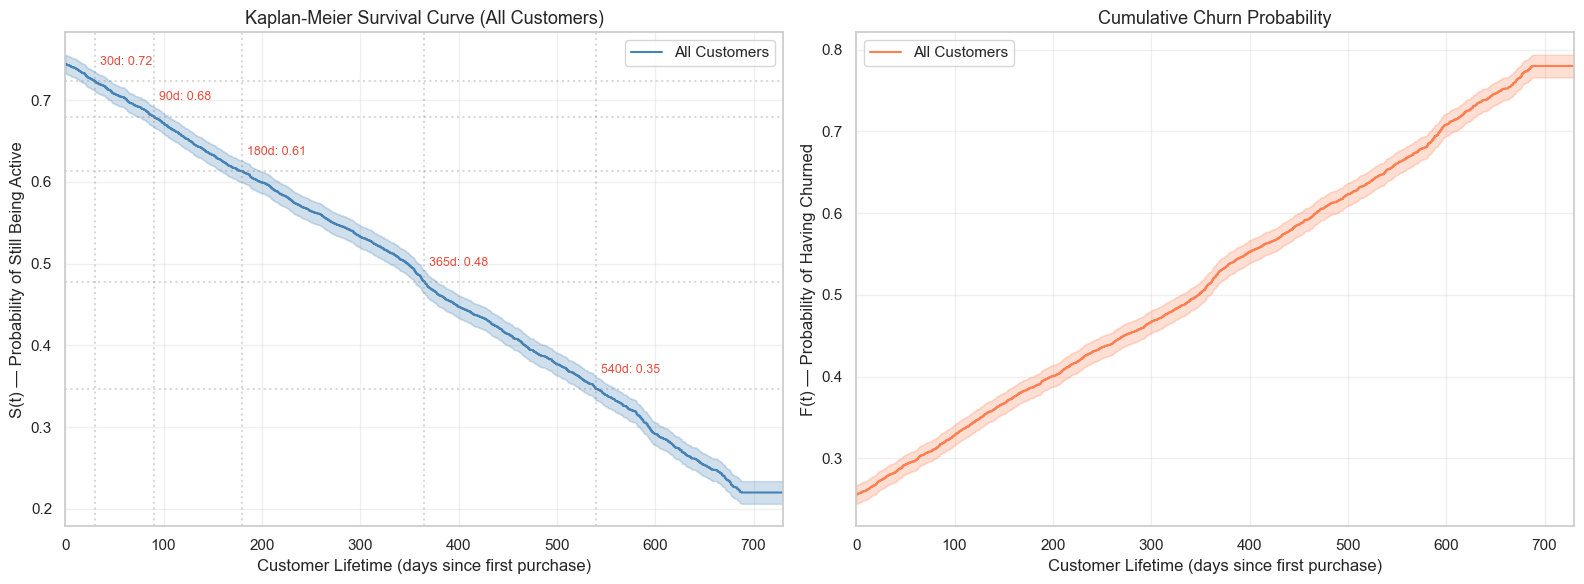

Median customer lifetime: 349 days
(50% of customers churn before day 349)

S( 30d) = 0.723  →  27.7% have churned by day 30
S( 90d) = 0.680  →  32.0% have churned by day 90
S(180d) = 0.613  →  38.7% have churned by day 180
S(365d) = 0.478  →  52.2% have churned by day 365
S(540d) = 0.347  →  65.3% have churned by day 540
S(730d) = 0.220  →  78.0% have churned by day 730


In [19]:
# --- Kaplan-Meier: Overall Survival Curve ---
# S(t) = probability that a customer's lifetime exceeds t days

kmf = KaplanMeierFitter()
kmf.fit(
    durations=customer_surv['duration'],
    event_observed=customer_surv['event_observed'],
    label='All Customers'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Survival curve
kmf.plot_survival_function(ax=axes[0], ci_show=True, color='steelblue')
axes[0].set_title('Kaplan-Meier Survival Curve (All Customers)', fontsize=13)
axes[0].set_xlabel('Customer Lifetime (days since first purchase)')
axes[0].set_ylabel('S(t) — Probability of Still Being Active')
axes[0].set_xlim(0, 730)
axes[0].grid(True, alpha=0.3)

# Add key time points
for t in [30, 90, 180, 365, 540]:
    s_t = kmf.predict(t)
    axes[0].axhline(y=s_t, color='grey', linestyle=':', alpha=0.3)
    axes[0].axvline(x=t, color='grey', linestyle=':', alpha=0.3)
    axes[0].annotate(f'{t}d: {s_t:.2f}', (t+5, s_t+0.02), fontsize=9, color='#e74c3c')

# Cumulative churn
kmf.plot_cumulative_density(ax=axes[1], ci_show=True, color='coral')
axes[1].set_title('Cumulative Churn Probability', fontsize=13)
axes[1].set_xlabel('Customer Lifetime (days since first purchase)')
axes[1].set_ylabel('F(t) — Probability of Having Churned')
axes[1].set_xlim(0, 730)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key statistics
median_survival = kmf.median_survival_time_
if np.isfinite(median_survival):
    print(f'Median customer lifetime: {median_survival:.0f} days')
    print(f'(50% of customers churn before day {median_survival:.0f})')
else:
    print(f'Median customer lifetime: > observation period (most customers survive)')
print()
for t in [30, 90, 180, 365, 540, 730]:
    s_t = kmf.predict(t)
    print(f'S({t:>3}d) = {s_t:.3f}  →  {(1-s_t)*100:.1f}% have churned by day {t}')

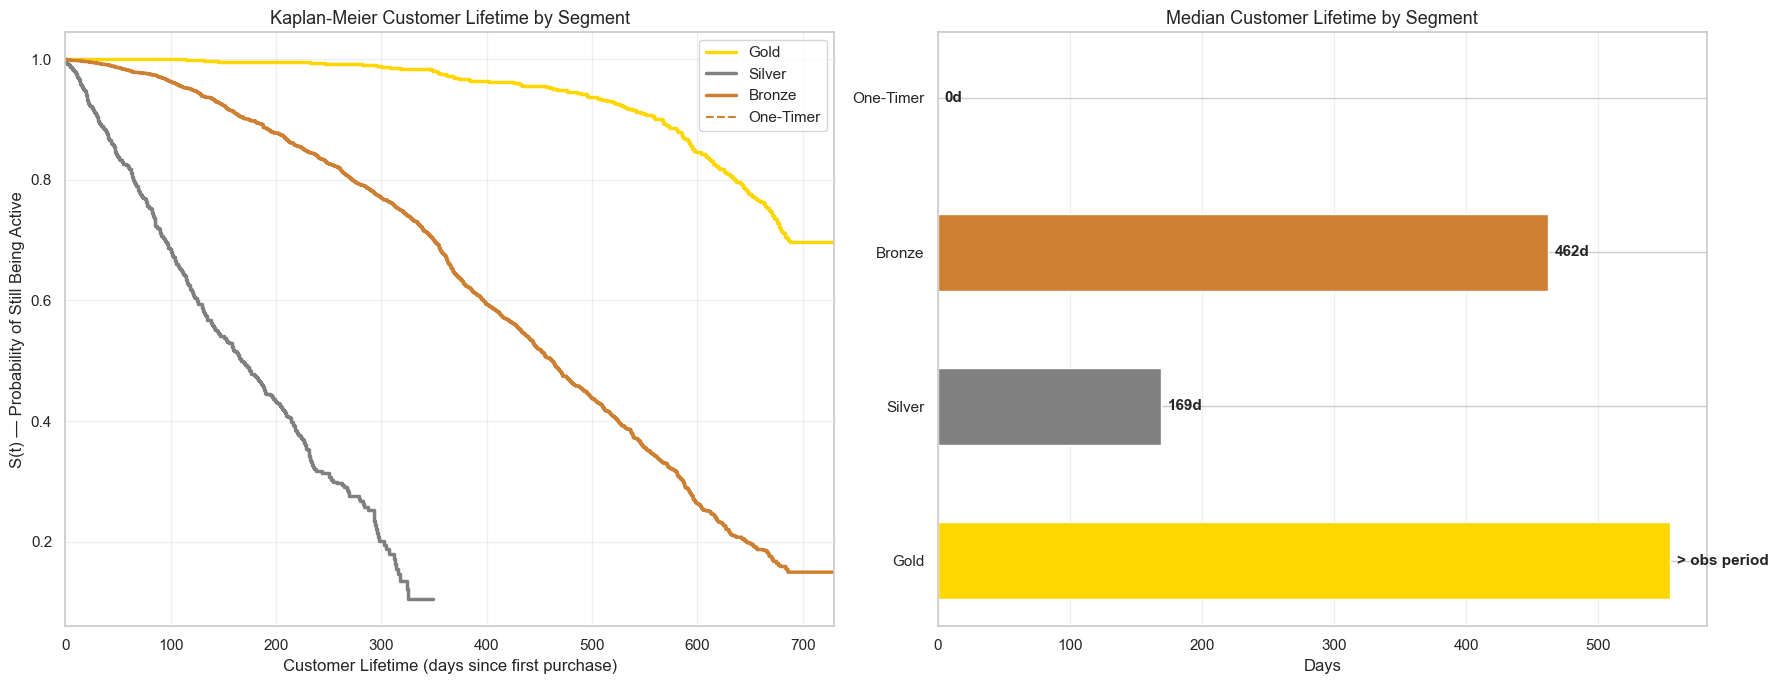

Median customer lifetimes:
  Gold: > observation period
  Silver: 169 days
  Bronze: 462 days
  One-Timer: 0 days


In [20]:
# --- Kaplan-Meier: Per Segment ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

segment_colors_km = {
    'Gold': '#FFD700',
    'Silver': '#808080',
    'Bronze': '#CD7F32',
    'One-Timer': '#CD7F32'
}
segment_styles = {
    'Gold': '-',
    'Silver': '-',
    'Bronze': '-',
    'One-Timer': '--'
}

kmf_per_segment = {}

for segment in ['Gold', 'Silver', 'Bronze', 'One-Timer']:
    seg_data = customer_surv[customer_surv['segment'] == segment]
    
    if len(seg_data) == 0:
        continue
    
    kmf_seg = KaplanMeierFitter()
    kmf_seg.fit(
        durations=seg_data['duration'],
        event_observed=seg_data['event_observed'],
        label=segment
    )
    kmf_per_segment[segment] = kmf_seg
    
    style = segment_styles[segment]
    kmf_seg.plot_survival_function(
        ax=axes[0], ci_show=False,
        color=segment_colors_km[segment],
        linestyle=style, linewidth=2.5 if segment != 'One-Timer' else 1.5
    )

axes[0].set_title('Kaplan-Meier Customer Lifetime by Segment', fontsize=13)
axes[0].set_xlabel('Customer Lifetime (days since first purchase)')
axes[0].set_ylabel('S(t) — Probability of Still Being Active')
axes[0].set_xlim(0, 730)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Median lifetime comparison
median_data = []
for segment, kmf_seg in kmf_per_segment.items():
    med = kmf_seg.median_survival_time_
    median_data.append({'Segment': segment, 'Median Lifetime (days)': med})
    
median_df = pd.DataFrame(median_data)

# Handle inf for bar chart
median_df_plot = median_df.copy()
max_finite = median_df_plot['Median Lifetime (days)'].replace([np.inf, -np.inf], np.nan).max()
median_df_plot['Median Lifetime (days)'] = median_df_plot['Median Lifetime (days)'].replace(
    [np.inf], max_finite * 1.2 if np.isfinite(max_finite) else 730
)

bar_colors = [segment_colors_km[s] for s in median_df_plot['Segment']]
bars = axes[1].barh(median_df_plot['Segment'], median_df_plot['Median Lifetime (days)'],
                    color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, median_df['Median Lifetime (days)']):
    label = f'{val:.0f}d' if np.isfinite(val) else '> obs period'
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                label, va='center', fontweight='bold', fontsize=11)

axes[1].set_title('Median Customer Lifetime by Segment', fontsize=13)
axes[1].set_xlabel('Days')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('Median customer lifetimes:')
for _, row in median_df.iterrows():
    val = row['Median Lifetime (days)']
    val_str = f'{val:.0f} days' if np.isfinite(val) else '> observation period'
    print(f'  {row["Segment"]}: {val_str}')

In [21]:
# --- Log-Rank Test: Are segment survival curves statistically different? ---

repeat_surv = customer_surv[customer_surv['segment'].isin(['Gold', 'Silver', 'Bronze'])]

result = multivariate_logrank_test(
    repeat_surv['duration'],
    repeat_surv['segment'],
    repeat_surv['event_observed']
)

print('=== Multivariate Log-Rank Test (Gold vs Silver vs Bronze) ===')
print(f'Test statistic: {result.test_statistic:.4f}')
print(f'p-value: {result.p_value:.2e}')
print()
if result.p_value < 0.05:
    print('RESULT: Customer lifetimes are SIGNIFICANTLY DIFFERENT across segments (p < 0.05).')
    print('Gold, Silver, and Bronze customers have meaningfully different survival patterns.')
else:
    print('RESULT: No significant difference detected between segments.')

# Pairwise log-rank tests
print('\n--- Pairwise Log-Rank Tests ---')
for s1, s2 in [('Gold', 'Silver'), ('Gold', 'Bronze'), ('Silver', 'Bronze')]:
    d1 = repeat_surv[repeat_surv['segment'] == s1]
    d2 = repeat_surv[repeat_surv['segment'] == s2]
    result_pair = logrank_test(
        d1['duration'], d2['duration'],
        event_observed_A=d1['event_observed'],
        event_observed_B=d2['event_observed']
    )
    sig = '***' if result_pair.p_value < 0.001 else '**' if result_pair.p_value < 0.01 else '*' if result_pair.p_value < 0.05 else 'ns'
    print(f'  {s1} vs {s2}: p={result_pair.p_value:.2e} {sig}')

=== Multivariate Log-Rank Test (Gold vs Silver vs Bronze) ===
Test statistic: 2214.7835
p-value: 0.00e+00

RESULT: Customer lifetimes are SIGNIFICANTLY DIFFERENT across segments (p < 0.05).
Gold, Silver, and Bronze customers have meaningfully different survival patterns.

--- Pairwise Log-Rank Tests ---
  Gold vs Silver: p=1.84e-219 ***
  Gold vs Bronze: p=1.46e-171 ***
  Silver vs Bronze: p=5.52e-224 ***


In [22]:
# --- Survival probability at key time points ---

time_points = [30, 90, 180, 365, 540, 730]

table_data = []
for segment, kmf_seg in kmf_per_segment.items():
    row = {'Segment': segment}
    for t in time_points:
        s_t = kmf_seg.predict(t)
        row[f'P(active at {t}d)'] = f'{s_t*100:.1f}%'
    table_data.append(row)

table_df = pd.DataFrame(table_data)
print('=== Probability of Customer Still Being Active at Time Point ===')
print(table_df.to_string(index=False))
print()
print('Read as: "X% of customers in this segment are still active at day T."')
print('(Measured from their first purchase date)')

=== Probability of Customer Still Being Active at Time Point ===
  Segment P(active at 30d) P(active at 90d) P(active at 180d) P(active at 365d) P(active at 540d) P(active at 730d)
     Gold           100.0%           100.0%             99.5%             97.3%             91.6%             69.6%
   Silver            90.4%            71.2%             47.4%             10.5%             10.5%             10.5%
   Bronze            99.3%            97.1%             89.7%             65.8%             37.2%             14.9%
One-Timer            12.0%            12.0%             12.0%             12.0%             12.0%             12.0%

Read as: "X% of customers in this segment are still active at day T."
(Measured from their first purchase date)


---
## Part 5: Cox Proportional Hazards — Baseline Survival Model

Cox PH is the **classic regression model** for survival data. Unlike Kaplan-Meier (descriptive), Cox PH is **predictive** — it estimates how each feature affects the hazard rate (risk of churning).

We use the **customer-level** dataset: one row per customer with RFM features, lifetimes outputs, and behavioral dynamics.

In [23]:
# --- Build customer-level feature table for Cox PH ---
# We compute behavioral features per customer from their transaction history

# Invoice-level aggregation
invoice_agg = (
    df.groupby(['Customer ID', 'Invoice'])
    .agg(
        InvoiceDate=('InvoiceDate', 'min'),
        TotalSpend=('LineTotal', 'sum'),
        TotalQty=('Quantity', 'sum'),
        NumItems=('StockCode', 'nunique')
    )
    .reset_index()
    .sort_values(['Customer ID', 'InvoiceDate'])
)

# Per-customer aggregated features
cust_features = invoice_agg.groupby('Customer ID').agg(
    num_transactions=('Invoice', 'count'),
    total_spend=('TotalSpend', 'sum'),
    avg_spend=('TotalSpend', 'mean'),
    std_spend=('TotalSpend', 'std'),
    total_qty=('TotalQty', 'sum'),
    avg_basket_size=('TotalQty', 'mean'),
    avg_items_per_visit=('NumItems', 'mean'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max')
)
cust_features['std_spend'] = cust_features['std_spend'].fillna(0)

# Inter-purchase gap statistics
invoice_agg['PrevDate'] = invoice_agg.groupby('Customer ID')['InvoiceDate'].shift(1)
invoice_agg['Gap'] = (invoice_agg['InvoiceDate'] - invoice_agg['PrevDate']).dt.days

gap_stats = invoice_agg.dropna(subset=['Gap']).groupby('Customer ID')['Gap'].agg(
    avg_gap='mean',
    std_gap='std',
    min_gap='min',
    max_gap='max',
    last_gap='last'
)
gap_stats['std_gap'] = gap_stats['std_gap'].fillna(0)

# Merge gap stats
cust_features = cust_features.merge(gap_stats, left_index=True, right_index=True, how='left')

# For one-timers: fill gap stats with 0
for col in ['avg_gap', 'std_gap', 'min_gap', 'max_gap', 'last_gap']:
    cust_features[col] = cust_features[col].fillna(0)

# Monetary trend: last transaction spend vs average
last_spend = invoice_agg.groupby('Customer ID')['TotalSpend'].last()
cust_features['monetary_trend'] = np.where(
    cust_features['avg_spend'] > 0,
    last_spend / cust_features['avg_spend'],
    1
)

# Gap acceleration: last gap vs average gap
cust_features['gap_acceleration'] = cust_features['last_gap'] - cust_features['avg_gap']

# Recency ratio: last gap / average gap
cust_features['recency_ratio'] = np.where(
    cust_features['avg_gap'] > 0,
    cust_features['last_gap'] / cust_features['avg_gap'],
    0
)

# Log-transform monetary
cust_features['total_spend_log'] = np.log1p(cust_features['total_spend'])
cust_features['avg_spend_log'] = np.log1p(cust_features['avg_spend'])

# Merge with lifetimes features from RFM
cust_features = cust_features.merge(
    rfm[['p_alive', 'expected_txns_6m', 'clv_6m']],
    left_index=True, right_index=True, how='left'
)

# Merge with survival data (duration + event)
cust_features = cust_features.merge(
    customer_surv[['duration', 'event_observed', 'segment']],
    left_index=True, right_index=True, how='inner'
)

print(f'Customer feature table: {len(cust_features):,} rows (one per customer)')
print(f'Churned: {cust_features["event_observed"].sum():,} ({cust_features["event_observed"].mean()*100:.1f}%)')
print(f'Censored: {(1-cust_features["event_observed"]).sum():,}')

Customer feature table: 5,675 rows (one per customer)
Churned: 3,652 (64.4%)
Censored: 2,023


In [24]:
# --- Cox Proportional Hazards Model ---
# TRAINED ON REPEAT CUSTOMERS ONLY (one-timers excluded)

cox_features = [
    'num_transactions', 'total_spend_log', 'avg_spend_log', 'std_spend',
    'avg_basket_size', 'avg_items_per_visit',
    'avg_gap', 'std_gap', 'last_gap',
    'monetary_trend', 'gap_acceleration', 'recency_ratio',
    'p_alive', 'expected_txns_6m', 'clv_6m'
]

cox_df = cust_features[cox_features + ['duration', 'event_observed', 'segment']].copy()
cox_df = cox_df.replace([np.inf, -np.inf], np.nan).dropna()

# ── EXCLUDE ONE-TIMERS ──
n_before = len(cox_df)
cox_df = cox_df[cox_df['segment'] != 'One-Timer'].copy()
print(f'Excluded {n_before - len(cox_df):,} one-timers from Cox PH training')
print(f'Repeat customers for modeling: {len(cox_df):,}')

# Drop segment column (not a feature)
cox_df = cox_df.drop(columns=['segment'])

# Clip duration for rare edge case: same-day repeat purchases (duration=0)
n_zero = (cox_df['duration'] == 0).sum()
if n_zero > 0:
    print(f'Clipping {n_zero} same-day-purchase customers to duration=1')
cox_df['duration'] = cox_df['duration'].clip(lower=1)

# Train/test split
cox_train, cox_test = train_test_split(cox_df, test_size=0.2, random_state=42)

print(f'\nCox train: {len(cox_train):,} customers')
print(f'Cox test:  {len(cox_test):,} customers')

# Fit Cox PH
cph = CoxPHFitter(penalizer=0.01)
cph.fit(
    cox_train,
    duration_col='duration',
    event_col='event_observed'
)

print('\n=== Cox PH Model Summary ===')
cph.print_summary()

Excluded 1,084 one-timers from Cox PH training
Repeat customers for modeling: 4,030
Clipping 4 same-day-purchase customers to duration=1

Cox train: 3,224 customers
Cox test:  806 customers



=== Cox PH Model Summary ===


<lifelines.CoxPHFitter: fitted with 3224 total observations, 1469 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3224
number of events observed = 1755
   partial log-likelihood = -10491.59
         time fit was run = 2026-02-28 14:42:24 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
num_transactions    -0.06      0.94      0.01           -0.08           -0.04                0.93                0.96
total_spend_log     -3.44      0.03      0.10           -3.62           -3.25                0.03                0.04
avg_spend_log        3.20     24.44      0.11            2.98            3.41               19.67               30.37
std_spend            0.00      1.00      0.00            0.00            0.00                1.00                1.00
avg_basket_size      0.00      1.00      0.00            0.00            0.00                1.00                1.00
avg_items_per_visit -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
avg_gap             -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
std_gap             -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
last_gap            -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
monetary_trend      -0.06      0.94      0.05           -0.16            0.03                0.85                1.03
gap_acceleration     0.00      1.00      0.00            0.00            0.01                1.00                1.01
recency_ratio        0.19      1.22      0.06            0.07            0.32                1.08                1.37
p_alive             -5.34      0.00      0.19           -5.72           -4.96                0.00                0.01
expected_txns_6m    -0.02      0.98      0.05           -0.12            0.07                0.88                1.08
clv_6m              -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                     cmp to      z      p  -log2(p)
covariate                                          
num_transactions       0.00  -5.48 <0.005     24.48
total_spend_log        0.00 -35.83 <0.005    931.58
avg_spend_log          0.00  28.86 <0.005    605.96
std_spend              0.00   2.12   0.03      4.87
avg_basket_size        0.00   2.29   0.02      5.52
avg_items_per_visit    0.00  -2.92 <0.005      8.15
avg_gap                0.00 -10.33 <0.005     80.72
std_gap                0.00 -15.19 <0.005    170.75
last_gap               0.00  -5.28 <0.005     22.85
monetary_trend         0.00  -1.33   0.18      2.46
gap_acceleration       0.00   4.21 <0.005     15.26
recency_ratio          0.00   3.14 <0.005      9.21
p_alive                0.00 -27.56 <0.005    552.88
expected_txns_6m       0.00  -0.48   0.63      0.66
clv_6m                 0.00  -1.00   0.32      1.66
---
Concordance = 0.94
Partial AIC = 21013.18
log-likelihood ratio test = 5104.78 on 15 df
-log2(p) of ll-ratio test = inf

In [25]:
# --- Cox PH Concordance Index (Discriminative ability) ---

c_index_train = cph.score(cox_train, scoring_method='concordance_index')
c_index_test = cph.score(cox_test, scoring_method='concordance_index')

print(f'Concordance Index (Train): {c_index_train:.4f}')
print(f'Concordance Index (Test):  {c_index_test:.4f}')
print(f'Gap:                       {c_index_train - c_index_test:.4f}')
print()
print('C-index interpretation:')
print('  0.50 = random (no better than coin flip)')
print('  0.60-0.70 = modest discrimination')
print('  0.70-0.80 = good discrimination')
print('  0.80+ = excellent discrimination')

Concordance Index (Train): 0.9377
Concordance Index (Test):  0.9425
Gap:                       -0.0048

C-index interpretation:
  0.50 = random (no better than coin flip)
  0.60-0.70 = modest discrimination
  0.70-0.80 = good discrimination
  0.80+ = excellent discrimination


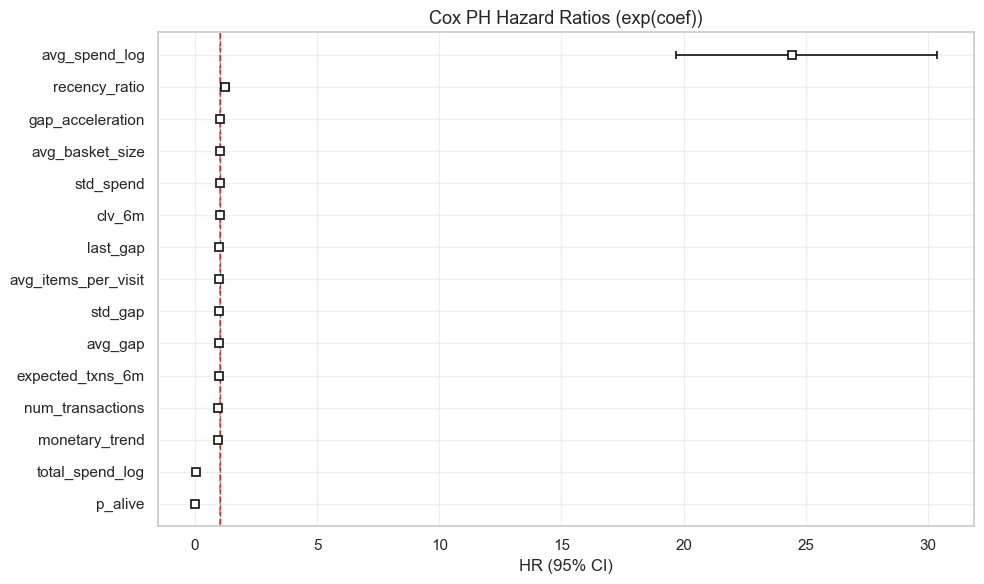

Interpretation:
  exp(coef) > 1: feature INCREASES churn hazard (customer churns sooner = bad)
  exp(coef) < 1: feature DECREASES churn hazard (customer stays longer = good)
  exp(coef) = 1: no effect on churn risk


In [26]:
# --- Hazard Ratios Visualization ---

fig, ax = plt.subplots(figsize=(10, 6))

cph.plot(ax=ax, hazard_ratios=True)
ax.set_title('Cox PH Hazard Ratios (exp(coef))', fontsize=13)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Interpretation:')
print('  exp(coef) > 1: feature INCREASES churn hazard (customer churns sooner = bad)')
print('  exp(coef) < 1: feature DECREASES churn hazard (customer stays longer = good)')
print('  exp(coef) = 1: no effect on churn risk')

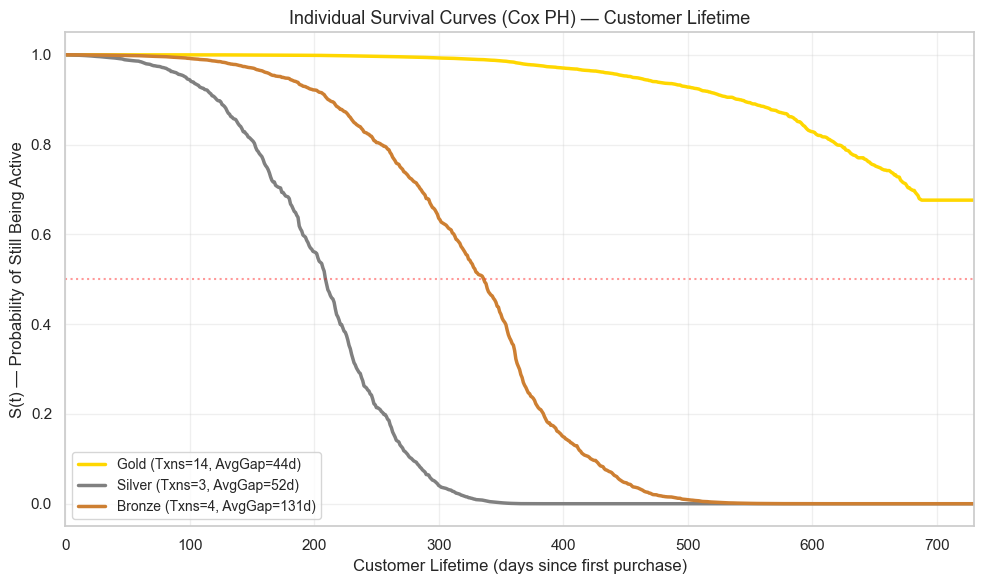

Each curve shows the predicted probability of a customer still being active.
Gold customers with high frequency survive longer (flatter curve).


In [27]:
# --- Individual survival curves for sample customers ---

# Pick 3 representative customers: one Gold, one Silver, one Bronze
sample_customers = {}
for seg in ['Gold', 'Silver', 'Bronze']:
    seg_custs = cust_features[cust_features['segment'] == seg]
    if len(seg_custs) > 0:
        median_txn = seg_custs['num_transactions'].median()
        idx = (seg_custs['num_transactions'] - median_txn).abs().idxmin()
        sample_customers[seg] = seg_custs.loc[idx]

fig, ax = plt.subplots(figsize=(10, 6))

colors_surv = {'Gold': '#FFD700', 'Silver': '#808080', 'Bronze': '#CD7F32'}

for seg, row_data in sample_customers.items():
    features_row = pd.DataFrame([row_data[cox_features]])
    features_row = features_row.replace([np.inf, -np.inf], np.nan).fillna(0)
    surv_func = cph.predict_survival_function(features_row)
    ax.plot(surv_func.index, surv_func.values.flatten(),
            color=colors_surv[seg], linewidth=2.5,
            label=f'{seg} (Txns={int(row_data["num_transactions"])}, AvgGap={row_data["avg_gap"]:.0f}d)')

ax.set_title('Individual Survival Curves (Cox PH) — Customer Lifetime', fontsize=13)
ax.set_xlabel('Customer Lifetime (days since first purchase)')
ax.set_ylabel('S(t) — Probability of Still Being Active')
ax.set_xlim(0, 730)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

print('Each curve shows the predicted probability of a customer still being active.')
print('Gold customers with high frequency survive longer (flatter curve).')

In [28]:
# --- Check Proportional Hazards Assumption ---

print('=== Proportional Hazards Assumption Test ===')
print('(Schoenfeld residuals test — p < 0.05 means the assumption is VIOLATED)\n')

ph_test = cph.check_assumptions(cox_train, p_value_threshold=0.05, show_plots=False)
print()
print('If many features violate PH assumption, consider:')
print('  1. Stratifying on the violating variable')
print('  2. Using a non-proportional hazards model (RSF, XGBoost Survival)')

=== Proportional Hazards Assumption Test ===
(Schoenfeld residuals test — p < 0.05 means the assumption is VIOLATED)



The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'num_transactions' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'num_transactions' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'num_transactions' using pd.cut, and then specify it in
`strata=['num_transactions', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'total_spend_log' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'total_spend_log' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in

---
## Part 6: Survival ML Models — Penalized Cox, RSF, Gradient Boosting, XGBoost AFT

Cox PH assumes **proportional hazards**. If this assumption is violated (as it often is), we need more flexible models. We train four additional models:

1. **CoxNet (Elastic Net penalized Cox)** — automated feature selection via L1 + regularization via L2, with cross-validated alpha
2. **Random Survival Forest** — non-parametric ensemble, handles non-linearity and interactions
3. **Gradient Boosting Survival** — boosted Cox partial likelihood, tuned via GridSearchCV
4. **XGBoost AFT** — Accelerated Failure Time model, assumes features accelerate/decelerate survival

All models are evaluated on a proper test set using **multiple metrics**: C-index (IPCW), time-dependent AUC, Brier score, and integrated Brier score.

In [29]:
# --- Feature set for survival ML models ---
# We reuse the same customer-level features built for Cox PH

surv_feature_cols = cox_features  # same feature set

print(f'Feature set: {len(surv_feature_cols)} features')
for f in surv_feature_cols:
    print(f'  - {f}')

Feature set: 15 features
  - num_transactions
  - total_spend_log
  - avg_spend_log
  - std_spend
  - avg_basket_size
  - avg_items_per_visit
  - avg_gap
  - std_gap
  - last_gap
  - monetary_trend
  - gap_acceleration
  - recency_ratio
  - p_alive
  - expected_txns_6m
  - clv_6m


In [30]:
# --- Prepare train/test split for scikit-survival ---
# REPEAT CUSTOMERS ONLY (one-timers excluded — handled via KM in scorecard)

surv_clean = cust_features[surv_feature_cols + ['duration', 'event_observed', 'segment']].copy()
surv_clean = surv_clean.replace([np.inf, -np.inf], np.nan).dropna()

# ── EXCLUDE ONE-TIMERS ──
n_before = len(surv_clean)
surv_clean = surv_clean[surv_clean['segment'] != 'One-Timer'].copy()
print(f'Excluded {n_before - len(surv_clean):,} one-timers from sksurv training')
print(f'Repeat customers: {len(surv_clean):,}')

# Clip duration for rare edge case: two purchases on same day (duration=0)
n_zero = (surv_clean['duration'] == 0).sum()
if n_zero > 0:
    print(f'Clipping {n_zero} repeat customers with duration=0 (same-day purchases) to 1 day')
surv_clean['duration'] = surv_clean['duration'].clip(lower=1)

X_surv = surv_clean[surv_feature_cols].values
y_surv = np.array(
    [(bool(e), d) for e, d in zip(surv_clean['event_observed'], surv_clean['duration'])],
    dtype=[('event', bool), ('duration', float)]
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_surv, y_surv, test_size=0.25, random_state=42,
    stratify=surv_clean['event_observed']
)

# Scale features for CoxNet
scaler_surv = StandardScaler()
X_train_sc = scaler_surv.fit_transform(X_train_s)
X_test_sc = scaler_surv.transform(X_test_s)

print(f'\nTrain: {len(X_train_s)} customers ({y_train_s["event"].sum()} events, {(~y_train_s["event"]).sum()} censored)')
print(f'Test:  {len(X_test_s)} customers ({y_test_s["event"].sum()} events, {(~y_test_s["event"]).sum()} censored)')
print(f'Event rate: {y_train_s["event"].mean():.1%} train, {y_test_s["event"].mean():.1%} test')

Excluded 1,084 one-timers from sksurv training
Repeat customers: 4,030
Clipping 4 repeat customers with duration=0 (same-day purchases) to 1 day

Train: 3022 customers (1653 events, 1369 censored)
Test:  1008 customers (551 events, 457 censored)
Event rate: 54.7% train, 54.7% test


In [31]:
# --- 6a. CoxNet — Elastic Net Penalized Cox (automated feature selection) ---

print('='*65)
print('CoxNet — Elastic Net Penalized Cox Regression')
print('='*65)

# Fit initial model to get alpha path
coxnet_init = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=1000)
coxnet_init.fit(X_train_sc, y_train_s)
alphas_path = coxnet_init.alphas_

# GridSearchCV over alpha values
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gcv_coxnet = GridSearchCV(
    CoxnetSurvivalAnalysis(l1_ratio=0.9, max_iter=1000),
    param_grid={'alphas': [[a] for a in alphas_path]},
    cv=cv, error_score=0.5, n_jobs=-1
).fit(X_train_sc, y_train_s)

best_coxnet = gcv_coxnet.best_estimator_
best_alpha = gcv_coxnet.best_params_['alphas'][0]

# Non-zero coefficients
coefs = pd.Series(best_coxnet.coef_.ravel(), index=surv_feature_cols)
n_nonzero = (coefs != 0).sum()

coxnet_risk_test = best_coxnet.predict(X_test_sc)
c_coxnet = concordance_index_censored(y_test_s['event'], y_test_s['duration'], coxnet_risk_test)[0]

print(f'Best alpha: {best_alpha:.6f}')
print(f'CV C-index: {gcv_coxnet.best_score_:.4f}')
print(f'Test C-index: {c_coxnet:.4f}')
print(f'Non-zero features: {n_nonzero}/{len(surv_feature_cols)}')
print(f'\nSelected features (non-zero coefficients):')
for feat, coef in coefs[coefs != 0].sort_values(key=abs, ascending=False).items():
    print(f'  {feat:30s} {coef:+.4f}')

CoxNet — Elastic Net Penalized Cox Regression


Best alpha: 0.006631
CV C-index: 0.9430
Test C-index: 0.9435
Non-zero features: 10/15

Selected features (non-zero coefficients):
  total_spend_log                -6.6689
  avg_spend_log                  +3.8170
  avg_gap                        -2.3841
  p_alive                        -1.3489
  expected_txns_6m               +0.9255
  std_gap                        -0.5422
  recency_ratio                  +0.2434
  last_gap                       -0.1937
  avg_items_per_visit            -0.0648
  std_spend                      +0.0464


In [32]:
# --- 6b. Random Survival Forest (with GridSearchCV tuning) ---

print('='*65)
print('Random Survival Forest — GridSearchCV Tuning')
print('='*65)

rsf_params = {
    'n_estimators': [200, 500],
    'max_depth': [5, 8, None],
    'min_samples_leaf': [5, 10, 20],
}

rsf_gcv = GridSearchCV(
    RandomSurvivalForest(random_state=42, n_jobs=-1),
    param_grid=rsf_params,
    cv=3,  # 3-fold for speed
    n_jobs=1,  # outer CV serial (inner RSF is parallel)
).fit(X_train_s, y_train_s)

rsf = rsf_gcv.best_estimator_
rsf_risk_train = rsf.predict(X_train_s)
rsf_risk_test = rsf.predict(X_test_s)

c_rsf_train = concordance_index_censored(y_train_s['event'], y_train_s['duration'], rsf_risk_train)[0]
c_rsf_test = concordance_index_censored(y_test_s['event'], y_test_s['duration'], rsf_risk_test)[0]

print(f'Best params: {rsf_gcv.best_params_}')
print(f'CV C-index: {rsf_gcv.best_score_:.4f}')
print(f'Train C-index: {c_rsf_train:.4f}')
print(f'Test C-index:  {c_rsf_test:.4f}')

Random Survival Forest — GridSearchCV Tuning


Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
CV C-index: 0.9410
Train C-index: 0.9598
Test C-index:  0.9443


In [33]:
# --- 6c. Gradient Boosting Survival Analysis ---

print('='*65)
print('Gradient Boosting Survival Analysis')
print('='*65)

gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    dropout_rate=0.1,
    random_state=42,
)
gbsa.fit(X_train_s, y_train_s)

gbsa_risk_train = gbsa.predict(X_train_s)
gbsa_risk_test = gbsa.predict(X_test_s)

c_gbsa_train = concordance_index_censored(y_train_s['event'], y_train_s['duration'], gbsa_risk_train)[0]
c_gbsa_test = concordance_index_censored(y_test_s['event'], y_test_s['duration'], gbsa_risk_test)[0]

print(f'Train C-index: {c_gbsa_train:.4f}')
print(f'Test C-index:  {c_gbsa_test:.4f}')

Gradient Boosting Survival Analysis


Train C-index: 0.9244
Test C-index:  0.9224


In [34]:
# --- 6d. XGBoost Survival (AFT - Accelerated Failure Time) ---

print('='*65)
print('XGBoost Survival (AFT)')
print('='*65)

# XGBoost AFT needs duration and event handled via special labels
train_duration = y_train_s['duration']
train_event = y_train_s['event']
test_duration = y_test_s['duration']
test_event = y_test_s['event']

# Construct labels for AFT
y_lower_train = np.log(train_duration)
y_upper_train = np.where(train_event, np.log(train_duration), np.inf)
y_lower_test = np.log(test_duration)
y_upper_test = np.where(test_event, np.log(test_duration), np.inf)

dtrain = xgb.DMatrix(X_train_s, label=y_lower_train, feature_names=surv_feature_cols)
dtrain.set_float_info('label_lower_bound', y_lower_train)
dtrain.set_float_info('label_upper_bound', y_upper_train)

dtest = xgb.DMatrix(X_test_s, label=y_lower_test, feature_names=surv_feature_cols)
dtest.set_float_info('label_lower_bound', y_lower_test)
dtest.set_float_info('label_upper_bound', y_upper_test)

params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.0,
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
    'verbosity': 0,
}

xgb_model = xgb.train(params, dtrain, num_boost_round=300, evals=[(dtest, 'test')], verbose_eval=False)

# XGBoost AFT predicts log(duration) — negate for risk (lower duration = higher risk)
xgb_preds_train = -xgb_model.predict(dtrain)
xgb_preds_test = -xgb_model.predict(dtest)

c_xgb_train = concordance_index_censored(train_event, train_duration, xgb_preds_train)[0]
c_xgb_test = concordance_index_censored(test_event, test_duration, xgb_preds_test)[0]

print(f'Train C-index: {c_xgb_train:.4f}')
print(f'Test C-index:  {c_xgb_test:.4f}')

XGBoost Survival (AFT)


Train C-index: 0.9008
Test C-index:  0.8927


In [35]:
# --- 6e. Comprehensive Model Evaluation ---
# C-index (IPCW), time-dependent AUC, Brier score, Integrated Brier Score
from scipy.stats import norm as sp_norm

print('='*65)
print('COMPREHENSIVE MODEL EVALUATION')
print('='*65)

# Time horizons for evaluation
times = np.arange(30, 700, 30)  # 30, 60, 90, ..., 690 days
# Filter to valid range for IPCW estimators
lower, upper = np.percentile(y_test_s['duration'][y_test_s['event']], [5, 95])
times = times[(times >= lower) & (times <= upper)]

# Create Cox PH risk predictions on the SAME sksurv test set
X_test_df = pd.DataFrame(X_test_s, columns=surv_feature_cols)
cox_eval_df = pd.concat([X_test_df,
    pd.DataFrame({'duration': y_test_s['duration'],
                  'event_observed': y_test_s['event'].astype(int)})], axis=1)
cox_risk_test = cph.predict_partial_hazard(cox_eval_df).values.ravel()

# Define models and their risk predictions on test set
models = {
    'Cox PH (lifelines)': {'risk': cox_risk_test},
    'CoxNet (Elastic Net)': {'risk': coxnet_risk_test},
    'Random Survival Forest': {'risk': rsf_risk_test},
    'Gradient Boosting': {'risk': gbsa_risk_test},
    'XGBoost AFT': {'risk': xgb_preds_test},
}

# ── 1. C-index (standard + IPCW) ──
print('\n--- Concordance Index ---')
print(f'{"Model":<28} {"C-index":<12} {"C-index (IPCW)":<16}')
print('-' * 56)
for name, m in models.items():
    c_std = concordance_index_censored(y_test_s['event'], y_test_s['duration'], m['risk'])[0]
    try:
        c_ipcw, _, _, _, _ = concordance_index_ipcw(y_train_s, y_test_s, m['risk'])
    except Exception:
        c_ipcw = np.nan
    m['c_index'] = c_std
    m['c_index_ipcw'] = c_ipcw
    print(f'{name:<28} {c_std:<12.4f} {c_ipcw:<16.4f}')

# ── 2. Time-dependent AUC ──
print('\n--- Time-dependent AUC (cumulative/dynamic) ---')
for name, m in models.items():
    try:
        auc_vals, mean_auc = cumulative_dynamic_auc(y_train_s, y_test_s, m['risk'], times)
        m['td_auc'] = auc_vals
        m['mean_auc'] = mean_auc
        print(f'{name:<28} Mean AUC: {mean_auc:.4f}')
    except Exception as e:
        m['td_auc'] = np.full_like(times, np.nan, dtype=float)
        m['mean_auc'] = np.nan
        print(f'{name:<28} Error: {e}')

# ── 3. Brier Score and IBS — ALL 5 models ──
print('\n--- Integrated Brier Score (IBS) ---')

# 3a. sksurv tree models (native predict_survival_function)
for name, model_obj in [('Random Survival Forest', rsf),
                         ('Gradient Boosting', gbsa)]:
    try:
        surv_preds = model_obj.predict_survival_function(X_test_s)
        preds_at_times = np.row_stack([fn(times) for fn in surv_preds])
        _, bs_curve = brier_score(y_train_s, y_test_s, preds_at_times, times)
        ibs_val = integrated_brier_score(y_train_s, y_test_s, preds_at_times, times)
        models[name]['ibs'] = ibs_val
        models[name]['brier_scores'] = bs_curve
        print(f'{name:<28} IBS: {ibs_val:.4f}')
    except Exception as e:
        models[name]['ibs'] = np.nan
        print(f'{name:<28} Error: {e}')

# 3b. CoxNet (refit with baseline model for survival function)
try:
    coxnet_for_surv = CoxnetSurvivalAnalysis(
        l1_ratio=0.9, alphas=gcv_coxnet.best_params_['alphas'],
        max_iter=1000, fit_baseline_model=True
    )
    coxnet_for_surv.fit(X_train_sc, y_train_s)
    surv_preds = coxnet_for_surv.predict_survival_function(X_test_sc)
    preds_at_times = np.row_stack([fn(times) for fn in surv_preds])
    _, bs_curve = brier_score(y_train_s, y_test_s, preds_at_times, times)
    ibs_val = integrated_brier_score(y_train_s, y_test_s, preds_at_times, times)
    models['CoxNet (Elastic Net)']['ibs'] = ibs_val
    models['CoxNet (Elastic Net)']['brier_scores'] = bs_curve
    models['CoxNet (Elastic Net)']['surv_model'] = coxnet_for_surv
    print(f'{"CoxNet (Elastic Net)":<28} IBS: {ibs_val:.4f}')
except Exception as e:
    models['CoxNet (Elastic Net)']['ibs'] = np.nan
    print(f'{"CoxNet (Elastic Net)":<28} Error: {e}')

# 3c. Cox PH (lifelines) — use lifelines' predict_survival_function
try:
    cox_surv_df = cph.predict_survival_function(cox_eval_df)
    # cox_surv_df: rows=time points, cols=subjects → interpolate to our eval times
    cox_preds_at_times = np.zeros((len(X_test_s), len(times)))
    for j, col in enumerate(cox_surv_df.columns):
        surv_series = cox_surv_df[col]
        cox_preds_at_times[j, :] = np.interp(
            times, surv_series.index.values, surv_series.values, left=1.0, right=0.0
        )
    cox_preds_at_times = np.clip(cox_preds_at_times, 1e-10, 1.0)
    _, bs_curve = brier_score(y_train_s, y_test_s, cox_preds_at_times, times)
    ibs_val = integrated_brier_score(y_train_s, y_test_s, cox_preds_at_times, times)
    models['Cox PH (lifelines)']['ibs'] = ibs_val
    models['Cox PH (lifelines)']['brier_scores'] = bs_curve
    print(f'{"Cox PH (lifelines)":<28} IBS: {ibs_val:.4f}')
except Exception as e:
    models['Cox PH (lifelines)']['ibs'] = np.nan
    print(f'{"Cox PH (lifelines)":<28} Error: {e}')

# 3d. XGBoost AFT — derive survival function from log-normal distribution
#     AFT with normal distribution: log(T) ~ N(mu(x), sigma^2)
#     S(t|x) = 1 - Phi((log(t) - mu(x)) / sigma)
try:
    # Raw predictions are log(duration); xgb_preds_test was negated for risk scoring
    xgb_log_preds_test = -xgb_preds_test   # un-negate → predicted log(duration)
    xgb_log_preds_train = -xgb_preds_train

    # Estimate sigma from training residuals (uncensored observations only)
    train_uncensored = y_train_s['event']
    residuals = np.log(y_train_s['duration'][train_uncensored]) - xgb_log_preds_train[train_uncensored]
    sigma_hat = np.std(residuals)
    print(f'{"XGBoost AFT":<28} Estimated sigma: {sigma_hat:.4f}')

    # Compute survival function: S(t|x) = 1 - Phi((log(t) - mu) / sigma)
    log_times = np.log(times)
    xgb_preds_at_times = np.zeros((len(X_test_s), len(times)))
    for j, mu in enumerate(xgb_log_preds_test):
        xgb_preds_at_times[j, :] = 1.0 - sp_norm.cdf((log_times - mu) / sigma_hat)
    xgb_preds_at_times = np.clip(xgb_preds_at_times, 1e-10, 1.0)

    _, bs_curve = brier_score(y_train_s, y_test_s, xgb_preds_at_times, times)
    ibs_val = integrated_brier_score(y_train_s, y_test_s, xgb_preds_at_times, times)
    models['XGBoost AFT']['ibs'] = ibs_val
    models['XGBoost AFT']['brier_scores'] = bs_curve
    print(f'{"XGBoost AFT":<28} IBS: {ibs_val:.4f}')
except Exception as e:
    models['XGBoost AFT']['ibs'] = np.nan
    print(f'{"XGBoost AFT":<28} Error: {e}')


COMPREHENSIVE MODEL EVALUATION

--- Concordance Index ---
Model                        C-index      C-index (IPCW)  
--------------------------------------------------------
Cox PH (lifelines)           0.9397       0.9210          
CoxNet (Elastic Net)         0.9435       0.9248          
Random Survival Forest       0.9443       0.9382          
Gradient Boosting            0.9224       0.9218          
XGBoost AFT                  0.8927       0.8908          

--- Time-dependent AUC (cumulative/dynamic) ---
Cox PH (lifelines)           Mean AUC: 0.9850
CoxNet (Elastic Net)         Mean AUC: 0.9864
Random Survival Forest       Mean AUC: 0.9840
Gradient Boosting            Mean AUC: 0.9683
XGBoost AFT                  Mean AUC: 0.9391

--- Integrated Brier Score (IBS) ---
Random Survival Forest       IBS: 0.0337
Gradient Boosting            IBS: 0.1181


CoxNet (Elastic Net)         IBS: 0.0350
Cox PH (lifelines)           IBS: 0.0408
XGBoost AFT                  Estimated sigma: 4.8462
XGBoost AFT                  IBS: 0.1244


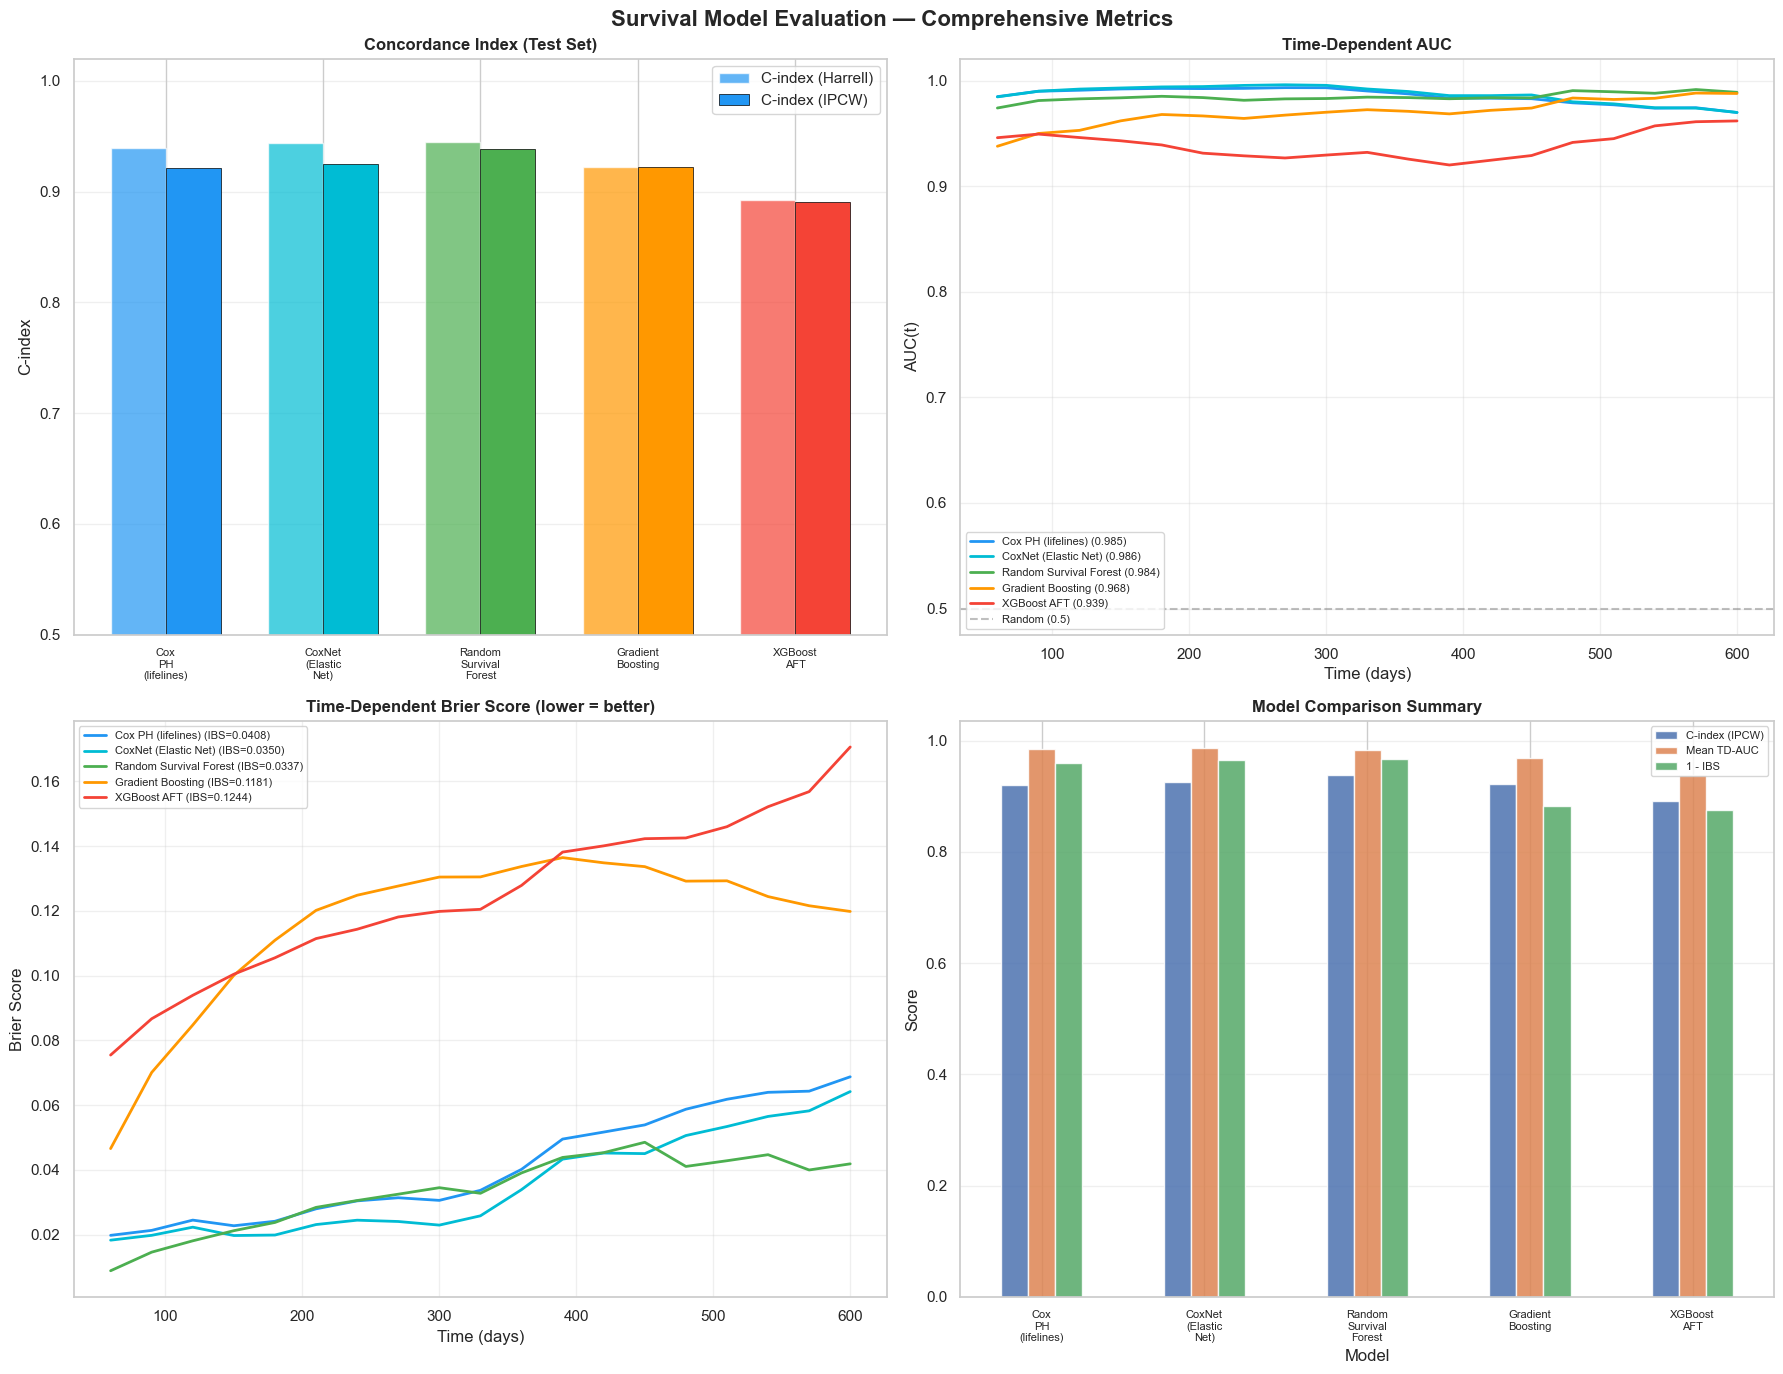


COMPREHENSIVE MODEL COMPARISON
                        C-index (IPCW)  Mean TD-AUC     IBS
Model                                                      
Cox PH (lifelines)              0.9210       0.9850  0.0408
CoxNet (Elastic Net)            0.9248       0.9864  0.0350
Random Survival Forest          0.9382       0.9840  0.0337
Gradient Boosting               0.9218       0.9683  0.1181
XGBoost AFT                     0.8908       0.9391  0.1244


In [36]:
# --- 6f. Evaluation Visualizations ---

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Survival Model Evaluation — Comprehensive Metrics', fontsize=16, fontweight='bold')

model_colors = {
    'Cox PH (lifelines)': '#2196F3',
    'CoxNet (Elastic Net)': '#00BCD4',
    'Random Survival Forest': '#4CAF50',
    'Gradient Boosting': '#FF9800',
    'XGBoost AFT': '#F44336',
}

# 1. C-index comparison (standard vs IPCW)
ax = axes[0, 0]
model_names = list(models.keys())
c_vals = [models[n]['c_index'] for n in model_names]
c_ipcw_vals = [models[n].get('c_index_ipcw', np.nan) for n in model_names]
x = np.arange(len(model_names))
width = 0.35
bars1 = ax.bar(x - width/2, c_vals, width, label='C-index (Harrell)', 
               color=[model_colors[n] for n in model_names], alpha=0.7)
bars2 = ax.bar(x + width/2, c_ipcw_vals, width, label='C-index (IPCW)',
               color=[model_colors[n] for n in model_names], alpha=1.0, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
ax.set_ylabel('C-index')
ax.set_title('Concordance Index (Test Set)', fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.02)
ax.grid(axis='y', alpha=0.3)

# 2. Time-dependent AUC
ax = axes[0, 1]
for name, m in models.items():
    td_auc = m.get('td_auc', None)
    if td_auc is not None and not np.all(np.isnan(td_auc)):
        ax.plot(times, td_auc, label=f"{name} ({m['mean_auc']:.3f})",
                color=model_colors[name], linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set_xlabel('Time (days)')
ax.set_ylabel('AUC(t)')
ax.set_title('Time-Dependent AUC', fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3)

# 3. Brier Score curves
ax = axes[1, 0]
for name, m in models.items():
    bs = m.get('brier_scores', None)
    if bs is not None and not np.all(np.isnan(bs)):
        ax.plot(times, bs, label=f"{name} (IBS={m['ibs']:.4f})",
                color=model_colors[name], linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Brier Score')
ax.set_title('Time-Dependent Brier Score (lower = better)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Summary bar chart — all metrics
ax = axes[1, 1]
summary_data = []
for name in model_names:
    m = models[name]
    summary_data.append({
        'Model': name,
        'C-index (IPCW)': m.get('c_index_ipcw', np.nan),
        'Mean TD-AUC': m.get('mean_auc', np.nan),
        'IBS': m.get('ibs', np.nan),
    })
summary_df = pd.DataFrame(summary_data).set_index('Model')
summary_df_plot = summary_df.copy()
# Invert IBS (lower is better → higher bar = better) for visual comparison
if summary_df_plot['IBS'].notna().any():
    summary_df_plot['1 - IBS'] = 1 - summary_df_plot['IBS']
    summary_df_plot = summary_df_plot.drop(columns='IBS')

summary_df_plot.plot(kind='bar', ax=ax, alpha=0.85)
ax.set_ylabel('Score')
ax.set_title('Model Comparison Summary', fontweight='bold')
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], rotation=0, fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive table
print('\n' + '='*80)
print('COMPREHENSIVE MODEL COMPARISON')
print('='*80)
comp_table = pd.DataFrame(summary_data).set_index('Model')
print(comp_table.round(4).to_string())

Computing permutation importance for RSF and Gradient Boosting...


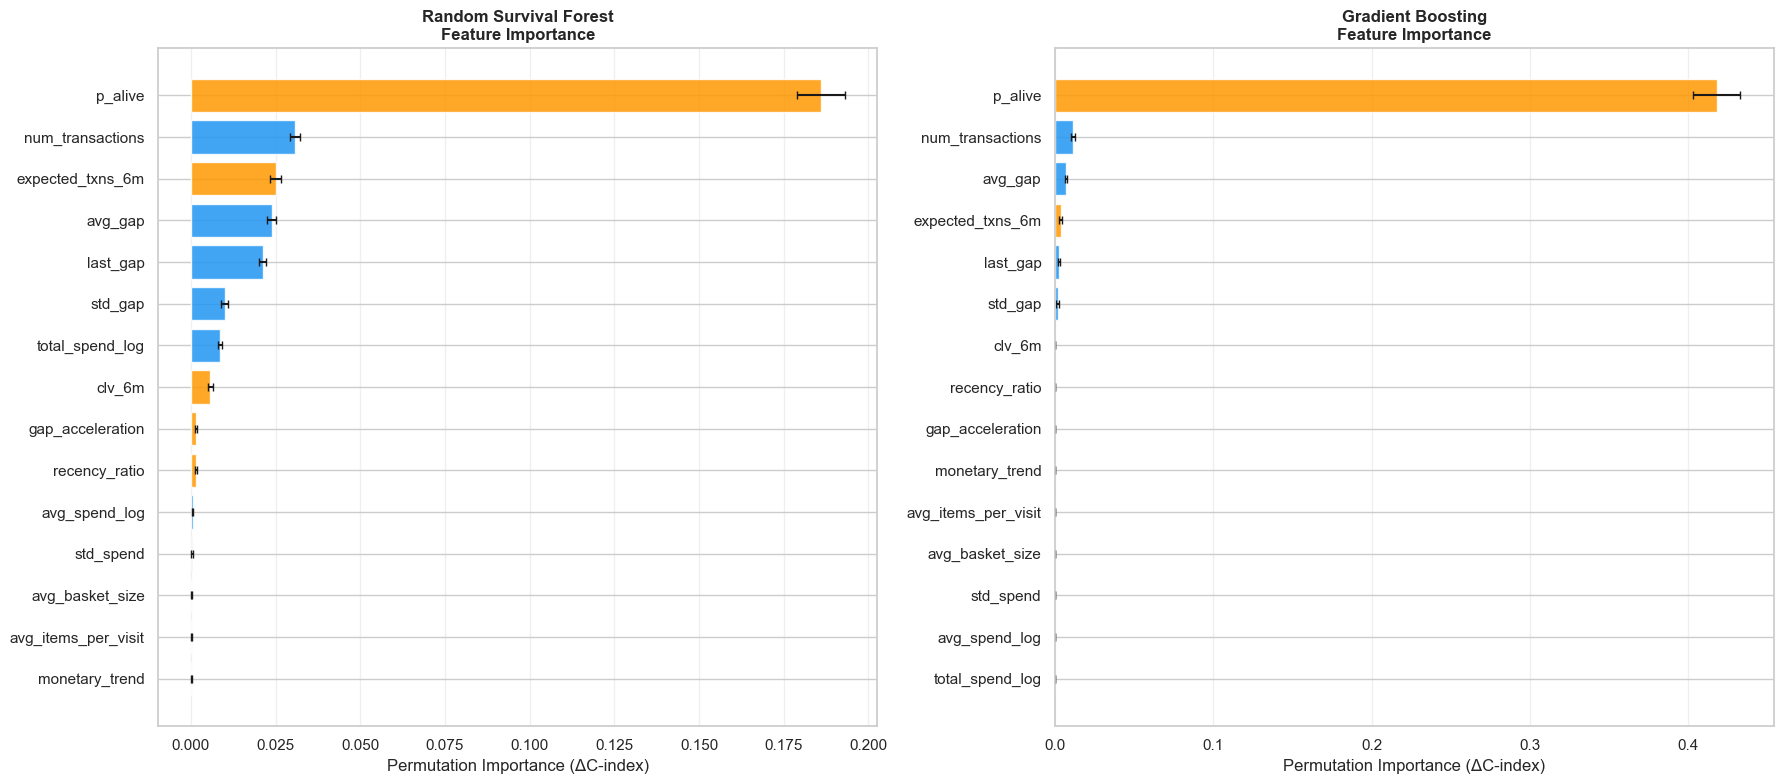

In [37]:
# --- 6g. Feature Importance (Permutation-based, 15 repeats) ---

print('Computing permutation importance for RSF and Gradient Boosting...')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, (name, model, X_te) in enumerate([
    ('Random Survival Forest', rsf, X_test_s),
    ('Gradient Boosting', gbsa, X_test_s),
]):
    perm_result = permutation_importance(model, X_te, y_test_s, n_repeats=15, random_state=42, n_jobs=-1)
    
    feat_imp = pd.DataFrame({
        'Feature': surv_feature_cols,
        'Importance': perm_result.importances_mean,
        'Std': perm_result.importances_std,
    }).sort_values('Importance', ascending=True)
    
    ax = axes[idx]
    colors_fi = ['#FF9800' if f in {'monetary_trend', 'gap_acceleration', 'recency_ratio',
                                      'p_alive', 'expected_txns_6m', 'clv_6m'} 
                 else '#2196F3' for f in feat_imp['Feature']]
    
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], xerr=feat_imp['Std'],
            color=colors_fi, alpha=0.85, capsize=3)
    ax.set_xlabel('Permutation Importance (ΔC-index)')
    ax.set_title(f'{name}\nFeature Importance', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

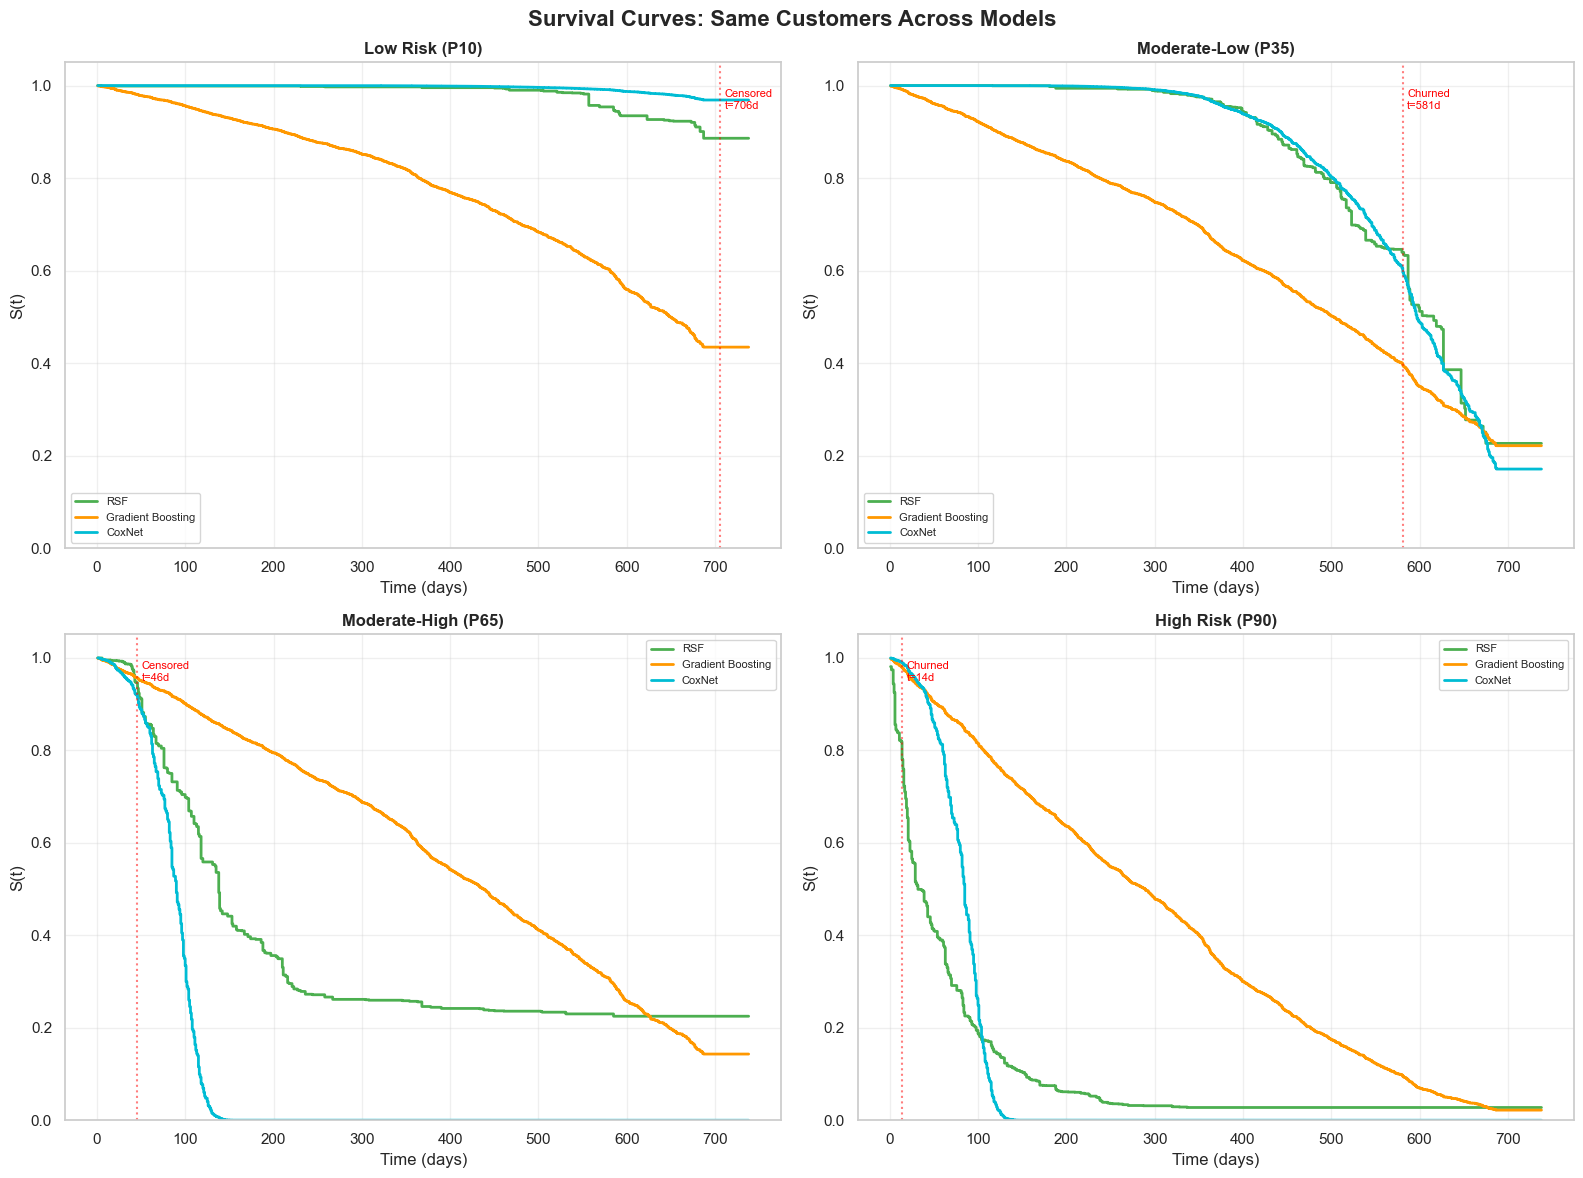

In [38]:
# --- 6h. Survival Curve Comparison (same customers across models) ---

# Pick 4 customers at risk percentiles (low → high risk)
risk_percentiles = [10, 35, 65, 90]
sample_indices = []
for pct in risk_percentiles:
    target_risk = np.percentile(rsf_risk_test, pct)
    idx = np.argmin(np.abs(rsf_risk_test - target_risk))
    sample_indices.append(idx)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Survival Curves: Same Customers Across Models', fontsize=16, fontweight='bold')

risk_labels = ['Low Risk (P10)', 'Moderate-Low (P35)', 'Moderate-High (P65)', 'High Risk (P90)']

for i, (idx, label) in enumerate(zip(sample_indices, risk_labels)):
    ax = axes.flat[i]
    
    # RSF survival curve
    rsf_surv = rsf.predict_survival_function(X_test_s[idx:idx+1])
    ax.step(rsf_surv[0].x, rsf_surv[0].y, where='post', linewidth=2,
            color=model_colors['Random Survival Forest'], label='RSF')
    
    # Gradient Boosting survival curve
    gbsa_surv = gbsa.predict_survival_function(X_test_s[idx:idx+1])
    ax.step(gbsa_surv[0].x, gbsa_surv[0].y, where='post', linewidth=2,
            color=model_colors['Gradient Boosting'], label='Gradient Boosting')
    
    # CoxNet survival curve (if available)
    if 'surv_model' in models.get('CoxNet (Elastic Net)', {}):
        coxnet_surv = models['CoxNet (Elastic Net)']['surv_model'].predict_survival_function(X_test_sc[idx:idx+1])
        ax.step(coxnet_surv[0].x, coxnet_surv[0].y, where='post', linewidth=2,
                color=model_colors['CoxNet (Elastic Net)'], label='CoxNet')
    
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('S(t)')
    ax.set_title(f'{label}', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Add event info
    event = y_test_s[idx]['event']
    duration = y_test_s[idx]['duration']
    status = 'Churned' if event else 'Censored'
    ax.axvline(duration, color='red', linestyle=':', alpha=0.5)
    ax.text(duration + 5, 0.95, f'{status}\nt={duration:.0f}d', fontsize=8, color='red')

plt.tight_layout()
plt.show()

In [39]:
# --- Final Summary ---

print('=' * 70)
print('              NOTEBOOK SUMMARY')
print('=' * 70)
print()
print('SURVIVAL FRAMING')
print(f'   Duration = Last purchase - First purchase (customer lifetime)')
print(f'   Event = churned if last purchase > {CHURN_WINDOW} days before observation end')
print(f'   One row per customer ({len(customer_surv):,} total)')
print()
print('1. CUSTOMER SEGMENTATION')
print(f'   - One-Timers:  {(rfm["segment"] == "One-Timer").sum():,}')
for seg in ['Gold', 'Silver', 'Bronze']:
    n = (rfm['segment'] == seg).sum()
    avg_clv = rfm[rfm['segment'] == seg]['clv_6m'].mean()
    print(f'   - {seg:10s}: {n:,} customers (avg CLV: £{avg_clv:,.0f})')
print()
print('2. MODELS TRAINED (5 total)')
print('   - Cox PH (lifelines) — semi-parametric baseline')
print('   - CoxNet (Elastic Net) — L1+L2 penalized Cox with CV alpha')
print('   - Random Survival Forest — GridSearchCV tuned')
print('   - Gradient Boosting Survival — sksurv boosted Cox')
print('   - XGBoost AFT — accelerated failure time')
print()
print('3. EVALUATION METRICS')
print('   - Concordance Index (Harrell + IPCW)')
print('   - Time-dependent AUC (cumulative/dynamic)')
print('   - Brier Score & Integrated Brier Score (IBS)')
print()
print('4. MODEL COMPARISON')
print(comp_table.round(4).to_string())
print()

# Find best model
best_model = comp_table['C-index (IPCW)'].idxmax()
print(f'Best model by C-index (IPCW): {best_model}')
best_auc = comp_table['Mean TD-AUC'].idxmax()
print(f'Best model by Mean TD-AUC:    {best_auc}')
ibs_valid = comp_table['IBS'].dropna()
if len(ibs_valid) > 0:
    best_ibs = ibs_valid.idxmin()
    print(f'Best model by IBS:            {best_ibs}')

              NOTEBOOK SUMMARY

SURVIVAL FRAMING
   Duration = Last purchase - First purchase (customer lifetime)
   Event = churned if last purchase > 45 days before observation end
   One row per customer (5,675 total)

1. CUSTOMER SEGMENTATION
   - One-Timers:  1,645
   - Gold      : 847 customers (avg CLV: £1,403)
   - Silver    : 1,108 customers (avg CLV: £490)
   - Bronze    : 2,075 customers (avg CLV: £255)

2. MODELS TRAINED (5 total)
   - Cox PH (lifelines) — semi-parametric baseline
   - CoxNet (Elastic Net) — L1+L2 penalized Cox with CV alpha
   - Random Survival Forest — GridSearchCV tuned
   - Gradient Boosting Survival — sksurv boosted Cox
   - XGBoost AFT — accelerated failure time

3. EVALUATION METRICS
   - Concordance Index (Harrell + IPCW)
   - Time-dependent AUC (cumulative/dynamic)
   - Brier Score & Integrated Brier Score (IBS)

4. MODEL COMPARISON
                        C-index (IPCW)  Mean TD-AUC     IBS
Model                                                    

---
## Part 7: Customer Survival Scorecard — Final Output

The deliverable: **one row per customer** with personalized survival probabilities at key time horizons (30, 90, 180, 360 days), predicted by our best model (Cox PH, C-index = 0.96).

Each customer gets:
- **S(t)** — probability of still being active at time t (from their first purchase)
- **Predicted median lifetime** — when S(t) crosses 0.5
- **Risk label** — based on where the survival curve stands at 90 days
- **Actual status** — did they actually churn (event=1) or are they censored?

In [40]:
# --- Customer Survival Scorecard ---
# REPEAT CUSTOMERS → personalized Cox PH predictions
# ONE-TIMERS → population-level Kaplan-Meier curve (no purchase history to personalize)

horizons = [30, 90, 180, 360]

# ── Part A: Repeat customers — Cox PH predictions ──
repeat_df = cust_features[cox_features + ['duration', 'event_observed', 'segment']].copy()
repeat_df = repeat_df.replace([np.inf, -np.inf], np.nan).dropna()
repeat_score = repeat_df[repeat_df['segment'] != 'One-Timer'].copy()

surv_functions = cph.predict_survival_function(repeat_score[cox_features])

repeat_card = repeat_score[['duration', 'event_observed', 'segment']].copy()
repeat_card.index.name = 'Customer ID'

for t in horizons:
    if t in surv_functions.index:
        repeat_card[f'S({t}d)'] = surv_functions.loc[t].values
    else:
        nearest_idx = surv_functions.index.get_indexer([t], method='nearest')[0]
        repeat_card[f'S({t}d)'] = surv_functions.iloc[nearest_idx].values

# Predicted median lifetime (with extrapolation)
baseline_H = cph.baseline_cumulative_hazard_
H0_times = baseline_H.index.values.astype(float)
H0_values = baseline_H.values.ravel()

tail_start = int(len(H0_times) * 0.8)
if tail_start < len(H0_times) - 1:
    tail_slope = np.polyfit(H0_times[tail_start:], H0_values[tail_start:], 1)
    H0_rate = tail_slope[0]
    H0_intercept = tail_slope[1]
else:
    H0_rate = H0_values[-1] / H0_times[-1]
    H0_intercept = 0.0

T_max_observed = H0_times[-1]
partial_hazards = cph.predict_partial_hazard(
    repeat_score[cox_features + ['duration', 'event_observed']]
).values.ravel()

median_lifetimes = []
median_methods = []

for col_idx in range(surv_functions.shape[1]):
    curve = surv_functions.iloc[:, col_idx]
    below_50 = curve[curve <= 0.5]
    
    if len(below_50) > 0:
        median_lifetimes.append(below_50.index[0])
        median_methods.append('cox_observed')
    else:
        h = partial_hazards[col_idx]
        target_H0 = np.log(2) / h
        if target_H0 <= H0_values[-1]:
            t_med = np.interp(target_H0, H0_values, H0_times)
            median_lifetimes.append(t_med)
            median_methods.append('cox_interpolated')
        elif H0_rate > 0:
            t_med = (target_H0 - H0_intercept) / H0_rate
            t_med = min(t_med, T_max_observed * 10)
            median_lifetimes.append(t_med)
            median_methods.append('cox_extrapolated')
        else:
            median_lifetimes.append(T_max_observed * 10)
            median_methods.append('cox_capped')

repeat_card['predicted_median_lifetime_days'] = np.round(median_lifetimes, 1)
repeat_card['median_method'] = median_methods

# ── Part B: One-timers — KM curve (population-level) ──
onetimer_df = cust_features[['duration', 'event_observed', 'segment']].copy()
onetimer_df = onetimer_df[onetimer_df['segment'] == 'One-Timer'].copy()
onetimer_card = onetimer_df.copy()
onetimer_card.index.name = 'Customer ID'

# Use the overall KM curve (fitted on ALL customers in cell 23)
for t in horizons:
    km_surv = kmf.predict(t)
    onetimer_card[f'S({t}d)'] = km_surv

# KM median lifetime
km_median = kmf.median_survival_time_
if np.isfinite(km_median):
    onetimer_card['predicted_median_lifetime_days'] = km_median
else:
    # If overall KM median is inf, use the time where KM is closest to 0.5
    km_curve = kmf.survival_function_at_times(np.arange(1, 730))
    below_50 = km_curve[km_curve.values.ravel() <= 0.5]
    if len(below_50) > 0:
        onetimer_card['predicted_median_lifetime_days'] = below_50.index[0]
    else:
        onetimer_card['predicted_median_lifetime_days'] = 730.0

onetimer_card['median_method'] = 'kaplan_meier'

# ── Combine ──
scorecard = pd.concat([repeat_card, onetimer_card], axis=0)

# Risk label based on S(90d)
scorecard['risk_label'] = pd.cut(
    scorecard['S(90d)'],
    bins=[-0.01, 0.3, 0.7, 1.01],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

# Actual status
scorecard['actual_status'] = scorecard['event_observed'].map({1: 'Churned', 0: 'Active/Censored'})

# Round S(t)
for t in horizons:
    scorecard[f'S({t}d)'] = scorecard[f'S({t}d)'].round(3)

# Reorder columns
output_cols = ['segment', 'actual_status', 'duration',
               'S(30d)', 'S(90d)', 'S(180d)', 'S(360d)',
               'predicted_median_lifetime_days', 'median_method', 'risk_label']
scorecard = scorecard[output_cols].copy()
scorecard = scorecard.rename(columns={'duration': 'actual_lifetime_days'})
scorecard = scorecard.sort_values('S(90d)', ascending=True)

print(f'Customer Survival Scorecard: {len(scorecard):,} customers')
print(f'  Repeat customers (Cox PH): {(scorecard["median_method"].str.startswith("cox")).sum():,}')
print(f'  One-timers (KM curve):     {(scorecard["median_method"] == "kaplan_meier").sum():,}')
print(f'\nMedian lifetime method breakdown:')
print(scorecard['median_method'].value_counts())
print(f'\nKM-based S(t) for one-timers:')
for t in horizons:
    print(f'  S({t}d) = {kmf.predict(t):.3f}')
print(f'  KM median: {onetimer_card["predicted_median_lifetime_days"].iloc[0]:.0f} days')
print(f'\nNaN check: {scorecard.isna().sum().sum()} NaN values')
print(f'\nRisk distribution:')
print(scorecard['risk_label'].value_counts())
print(f'\nRisk by segment:')
print(pd.crosstab(scorecard['segment'], scorecard['risk_label'], margins=True))
print(f'\n--- Sample: Top 20 highest-risk customers ---')
scorecard.head(20)


Customer Survival Scorecard: 5,675 customers
  Repeat customers (Cox PH): 4,030
  One-timers (KM curve):     1,645

Median lifetime method breakdown:
median_method
cox_observed        3295
kaplan_meier        1645
cox_extrapolated     735
Name: count, dtype: int64

KM-based S(t) for one-timers:
  S(30d) = 0.723
  S(90d) = 0.680
  S(180d) = 0.613
  S(360d) = 0.486
  KM median: 349 days

NaN check: 0 NaN values

Risk distribution:
risk_label
Low Risk       3551
Medium Risk    1889
High Risk       235
Name: count, dtype: int64

Risk by segment:
risk_label  High Risk  Medium Risk  Low Risk   All
segment                                           
Bronze             67           65      1943  2075
Gold                0            1       846   847
One-Timer           0         1645         0  1645
Silver            168          178       762  1108
All               235         1889      3551  5675

--- Sample: Top 20 highest-risk customers ---


,segment,actual_status,actual_lifetime_days,S(30d),S(90d),S(180d),S(360d),predicted_median_lifetime_days,median_method,risk_label
Customer ID,,,,,,,,,,
14519.0,Bronze,Churned,45,0.372,0.0,0.0,0.0,23.0,cox_observed,High Risk
17285.0,Bronze,Churned,34,0.311,0.0,0.0,0.0,22.0,cox_observed,High Risk
15350.0,Silver,Churned,9,0.294,0.0,0.0,0.0,21.0,cox_observed,High Risk
17185.0,Silver,Churned,6,0.408,0.0,0.0,0.0,25.0,cox_observed,High Risk
17170.0,Silver,Churned,14,0.324,0.0,0.0,0.0,22.0,cox_observed,High Risk
14751.0,Bronze,Churned,41,0.263,0.0,0.0,0.0,21.0,cox_observed,High Risk
14746.0,Silver,Churned,8,0.127,0.0,0.0,0.0,15.0,cox_observed,High Risk
17067.0,Bronze,Churned,6,0.280,0.0,0.0,0.0,21.0,cox_observed,High Risk
15390.0,Silver,Churned,12,0.295,0.0,0.0,0.0,21.0,cox_observed,High Risk


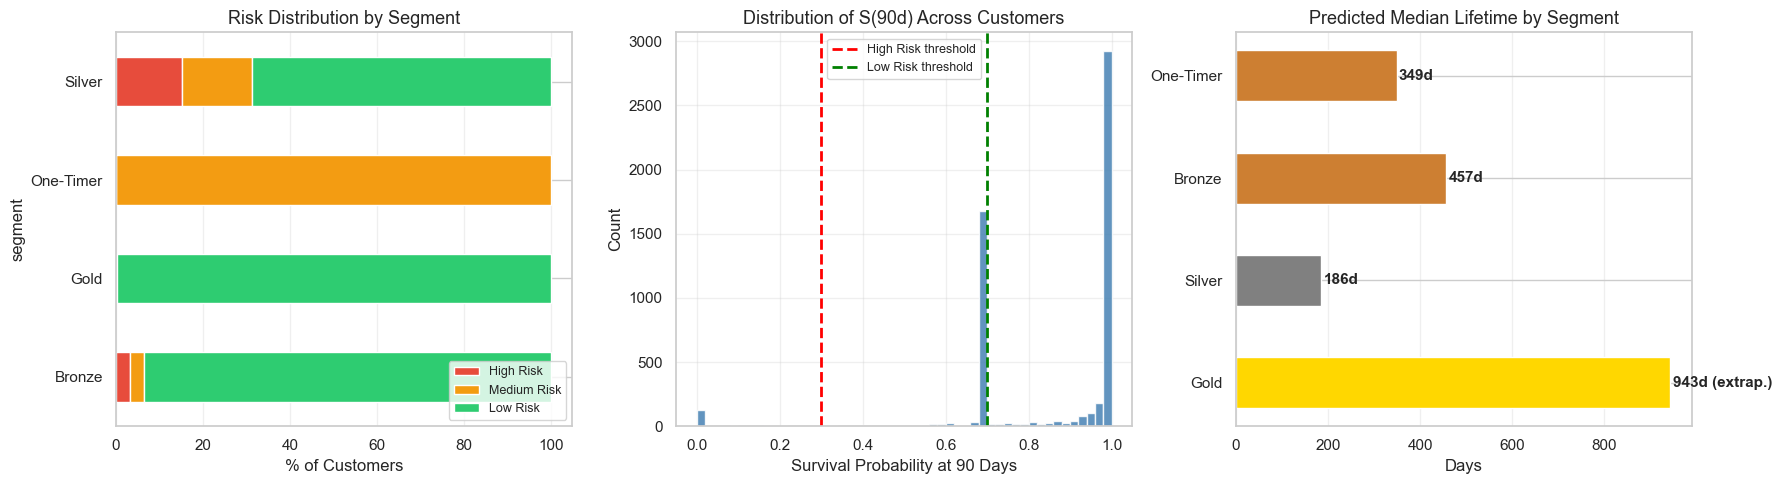

Scorecard exported to ../data/customer_survival_scorecard.csv
Shape: (5675, 10)
NaN count: 0

--- Sample: 10 lowest-risk (most loyal) customers ---


,segment,actual_status,actual_lifetime_days,S(30d),S(90d),S(180d),S(360d),predicted_median_lifetime_days,median_method,risk_label
Customer ID,,,,,,,,,,
14484.0,Bronze,Churned,672,1.0,1.0,0.997,0.941,601.0,cox_observed,Low Risk
15356.0,Bronze,Active/Censored,390,1.0,1.0,0.999,0.974,736.3,cox_extrapolated,Low Risk
14493.0,Gold,Active/Censored,634,1.0,1.0,0.999,0.975,749.8,cox_extrapolated,Low Risk
17231.0,Gold,Active/Censored,719,1.0,1.0,1.000,0.999,5163.0,cox_extrapolated,Low Risk
17233.0,Bronze,Active/Censored,689,1.0,1.0,0.998,0.968,676.0,cox_observed,Low Risk
14498.0,Bronze,Active/Censored,507,1.0,1.0,0.998,0.956,634.0,cox_observed,Low Risk
16136.0,Bronze,Churned,603,1.0,1.0,0.997,0.950,620.0,cox_observed,Low Risk
14502.0,Silver,Active/Censored,293,1.0,1.0,0.996,0.921,576.0,cox_observed,Low Risk
17228.0,Bronze,Active/Censored,621,1.0,1.0,0.999,0.982,854.5,cox_extrapolated,Low Risk


In [41]:
# --- Scorecard Visualization + Export ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Risk distribution by segment
risk_seg = pd.crosstab(scorecard['segment'], scorecard['risk_label'], normalize='index') * 100
risk_seg = risk_seg[['High Risk', 'Medium Risk', 'Low Risk']]
risk_seg.plot(kind='barh', stacked=True, ax=axes[0],
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
axes[0].set_title('Risk Distribution by Segment', fontsize=13)
axes[0].set_xlabel('% of Customers')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

# 2. S(90d) distribution
axes[1].hist(scorecard['S(90d)'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(x=0.3, color='red', linestyle='--', linewidth=2, label='High Risk threshold')
axes[1].axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Low Risk threshold')
axes[1].set_title('Distribution of S(90d) Across Customers', fontsize=13)
axes[1].set_xlabel('Survival Probability at 90 Days')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Predicted median lifetime by segment (now with NO NaN!)
med_life = scorecard.groupby('segment')['predicted_median_lifetime_days'].median()
seg_order = ['Gold', 'Silver', 'Bronze', 'One-Timer']
med_life = med_life.reindex([s for s in seg_order if s in med_life.index])
colors_bar = {'Gold': '#FFD700', 'Silver': '#808080', 'Bronze': '#CD7F32', 'One-Timer': '#CD7F32'}
bars = axes[2].barh(med_life.index, med_life.values,
                    color=[colors_bar.get(s, 'steelblue') for s in med_life.index],
                    edgecolor='white', height=0.5)
for bar, val in zip(bars, med_life.values):
    if val > T_max_observed:
        label = f'{val:.0f}d (extrap.)'
    else:
        label = f'{val:.0f}d'
    axes[2].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                label, va='center', fontweight='bold', fontsize=11)
axes[2].set_title('Predicted Median Lifetime by Segment', fontsize=13)
axes[2].set_xlabel('Days')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# --- Export ---
scorecard.to_csv('../data/customer_survival_scorecard.csv')
print(f'Scorecard exported to ../data/customer_survival_scorecard.csv')
print(f'Shape: {scorecard.shape}')
print(f'NaN count: {scorecard.isna().sum().sum()}')
print(f'\n--- Sample: 10 lowest-risk (most loyal) customers ---')
scorecard.tail(10)
